In [6]:
from google.colab import files
uploaded = files.upload()

Saving default of credit card clients.xls to default of credit card clients.xls


In [7]:
import pandas as pd
import numpy as np

base_sucia = pd.read_excel("default of credit card clients.xls")
base_sucia.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [8]:
#Cambiamos la primera fila por los nombres de las columnas y dejamos "ID" como índice
base = base_sucia.rename(columns=base_sucia.iloc[0]).drop(base_sucia.index[0])
base = base.set_index("ID")

base.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [9]:
def revisar_consistencia(df: pd.DataFrame, tipos_esperados: dict = None):
    """
    Revisa consistencia básica de un DataFrame:
    - Valores nulos por columna
    - Tipos de datos actuales
    - Comparación contra tipos esperados (opcional)

    Parámetros:
    df : pd.DataFrame
        Dataset a revisar
    tipos_esperados : dict (opcional)
        Diccionario con tipos esperados por columna, ej:
        {"col1": "int64", "col2": "float64", "col3": "object"}
    """
    print("=== Valores nulos por columna ===")
    print(df.isnull().sum())
    print("\n=== Tipos de datos actuales ===")
    print(df.dtypes)

    if tipos_esperados:
        print("\n=== Comparación contra tipos esperados ===")
        for col, tipo in tipos_esperados.items():
            if col in df.columns:
                actual = str(df[col].dtype)
                if actual != tipo:
                    print(f"Columna '{col}' esperada {tipo}, encontrada {actual}")
            else:
                print(f"Columna '{col}' no existe en el DataFrame")

    print("\n=== Valores únicos por columna (para detectar rarezas) ===")
    for col in df.columns:
        uniques = df[col].nunique()
        print(f"{col}: {uniques} valores únicos")

# Ejemplo de uso:
tipos_esperados = {
    "LIMIT_BAL": "float64",
    "SEX": "int64",
    "EDUCATION": "int64",
    "MARRIAGE": "int64",
    "AGE": "int64",
    "PAY_0": "int64",
    "PAY_2": "int64",
    "PAY_3": "int64",
    "PAY_4": "int64",
    "PAY_5": "int64",
    "PAY_6": "int64",
    "BILL_AMT1": "float64",
    "BILL_AMT2": "float64",
    "BILL_AMT3": "float64",
    "BILL_AMT4": "float64",
    "BILL_AMT5": "float64",
    "BILL_AMT6": "float64",
    "PAY_AMT1": "float64",
    "PAY_AMT2": "float64",
    "PAY_AMT3": "float64",
    "PAY_AMT4": "float64",
    "PAY_AMT5": "float64",
    "PAY_AMT6": "float64",
    "default payment next month": "int64"
}
revisar_consistencia(base, tipos_esperados)

=== Valores nulos por columna ===
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

=== Tipos de datos actuales ===
LIMIT_BAL                     object
SEX                           object
EDUCATION                     object
MARRIAGE                      object
AGE 

## Cambio de tipo de datos
Todos los datos están en tipo objeto, los transformamos para evitar errores:

In [10]:
base = base.astype({
    "LIMIT_BAL": "float",
    "SEX": "int64",
    "EDUCATION": "int64",
    "MARRIAGE": "int64",
    "AGE": "int64",
    "PAY_0": "int64",
    "PAY_2": "int64",
    "PAY_3": "int64",
    "PAY_4": "int64",
    "PAY_5": "int64",
    "PAY_6": "int64",
    "BILL_AMT1": "float64",
    "BILL_AMT2": "float64",
    "BILL_AMT3": "float64",
    "BILL_AMT4": "float64",
    "BILL_AMT5": "float64",
    "BILL_AMT6": "float64",
    "PAY_AMT1": "float64",
    "PAY_AMT2": "float64",
    "PAY_AMT3": "float64",
    "PAY_AMT4": "float64",
    "PAY_AMT5": "float64",
    "PAY_AMT6": "float64",
    "default payment next month": "int64"
})

# Analisis exploratorio

### Porcentaje de default vs no default

In [11]:
#Observamos que el 77.88% de las cuentas no ha caído en default
tabla_default = base["default payment next month"].value_counts().to_frame("frecuencia")

tabla_default["porcentaje"] = (
    base["default payment next month"]
    .value_counts(normalize=True) * 100
)

tabla_default

,frecuencia,porcentaje
default payment next month,,
0,23364,77.88
1,6636,22.12


### Revisión de datos válidos
Observamos que hay valores que tienen valores que no concuerdan con lo descrito, como educación en 0, 5 y 6, estado marital en 0 y sexo y default en 0

In [12]:
categorias_validas = {
    "SEX": [1, 2],
    "EDUCATION": [1, 2, 3, 4],
    "MARRIAGE": [1, 2, 3],
    "default payment next month": [0, 1]
}

for col, validas in categorias_validas.items():
    filas_raras = base[~base[col].isin(validas)]

    print("=" * 60)
    print(f"Columna: {col}")
    print(f"Número de filas raras: {len(filas_raras)}")
    print("Valores raros encontrados:")
    print(filas_raras[col].value_counts(dropna=False))
    print()

Columna: SEX
Número de filas raras: 0
Valores raros encontrados:
Series([], Name: count, dtype: int64)

Columna: EDUCATION
Número de filas raras: 345
Valores raros encontrados:
EDUCATION
5    280
6     51
0     14
Name: count, dtype: int64

Columna: MARRIAGE
Número de filas raras: 54
Valores raros encontrados:
MARRIAGE
0    54
Name: count, dtype: int64

Columna: default payment next month
Número de filas raras: 0
Valores raros encontrados:
Series([], Name: count, dtype: int64)



#### Asumiremos que los valores 5,6 y 0 de educación, y los 0 del estatus marital corresponden a otros:

In [13]:
base["EDUCATION"] = base["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})

base["MARRIAGE"] = base["MARRIAGE"].replace({
    0: 3
})

#### Revisón de valores negativos donde no corresponde:
No se observan valores negativos en el crédito obtenido, la edad o los pagos realizados

In [14]:
no_negativas = [
    "LIMIT_BAL",
    "AGE",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]
for col in no_negativas:
    negativos = (base[col] < 0).sum()
    print(col, negativos)

LIMIT_BAL 0
AGE 0
PAY_AMT1 0
PAY_AMT2 0
PAY_AMT3 0
PAY_AMT4 0
PAY_AMT5 0
PAY_AMT6 0


#### Revisión de filas duplicadas
Observamos que hay 35 filas que, excepto por ID son iguales; suponiendo que es extremadamente raro que dos personas tengan el mismo sexo, eduación, edad y hayan hecho el mismo crédito y los mismos pagos, asumiremos que se duplicaron y las eliminaremos

In [15]:
duplicados = base[base.duplicated(keep=False)]

duplicados.sort_values(by=list(base.columns))

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
ID,,,,,,,,,,,,,,,,,,,,,
12431,20000.0,1,2,2,24,2,2,4,4,4,...,1650.0,1650.0,1650.0,0.0,0.0,0.0,0.0,0.0,0.0,1
14295,20000.0,1,2,2,24,2,2,4,4,4,...,1650.0,1650.0,1650.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1760,50000.0,1,2,2,26,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
10251,50000.0,1,2,2,26,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
7171,50000.0,2,1,2,23,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27967,360000.0,2,1,2,27,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
18326,360000.0,2,1,2,29,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
22163,360000.0,2,1,2,29,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [16]:
#Borramos los duplicados
base = base.drop_duplicates(keep="first")

### Análisis estadistico
A simple vista resalta que el 75% de los créditos se ubiquen hasta
 240,000 , pero el salto en el último cuantil es alto, llegando a 1,000,000. Lo cual no necesariamente es un error pero si un punto a tener en cuenta

In [17]:
base.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,29965.0,167442.005006,129760.135222,10000.0,50000.0,140000.0,240000.0,1000000.0
SEX,29965.0,1.603738,0.489128,1.0,1.0,2.0,2.0,2.0
EDUCATION,29965.0,1.842750,0.744513,1.0,1.0,2.0,2.0,4.0
MARRIAGE,29965.0,1.557283,0.521431,1.0,1.0,2.0,2.0,3.0
AGE,29965.0,35.487969,9.219459,21.0,28.0,34.0,41.0,79.0
PAY_0,29965.0,-0.016753,1.123492,-2.0,-1.0,0.0,0.0,8.0
PAY_2,29965.0,-0.131854,1.196322,-2.0,-1.0,0.0,0.0,8.0
PAY_3,29965.0,-0.164392,1.195878,-2.0,-1.0,0.0,0.0,8.0
PAY_4,29965.0,-0.218922,1.168175,-2.0,-1.0,0.0,0.0,8.0
PAY_5,29965.0,-0.264509,1.132220,-2.0,-1.0,0.0,0.0,8.0


# Añadimos variables auxiliares

In [18]:
# Columnas base
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

# Copia limpia del historial de atraso:
# valores <= 0 se tratan como "sin atraso"
delay_data = base[pay_cols].clip(lower=0)

# Promedio de atraso
base["avg_delay"] = delay_data.mean(axis=1)

# Máximo atraso observado
base["max_delay"] = delay_data.max(axis=1)

# Número de meses con atraso
base["months_delayed"] = (delay_data > 0).sum(axis=1)

# Indicador de atraso reciente
base["recent_delay"] = (base["PAY_0"] > 0).astype(int)

# Utilización promedio del crédito
utilization = base[bill_cols].div(base["LIMIT_BAL"], axis=0)
base["avg_utilization"] = utilization.mean(axis=1)

# Máxima utilización del crédito
base["max_utilization"] = utilization.max(axis=1)

# Ratio de pago total sobre saldo total
total_payment = base[pay_amt_cols].sum(axis=1)
total_bill = base[bill_cols].sum(axis=1)

base["total_payment_ratio"] = np.where(
    total_bill > 0,
    total_payment / total_bill,
    0
)

# Tendencia del saldo facturado
# BILL_AMT1 = septiembre, BILL_AMT6 = abril
base["bill_trend"] = base["BILL_AMT1"] - base["BILL_AMT6"]

# Tendencia del atraso
# PAY_0 = septiembre, PAY_6 = abril
base["delay_trend"] = delay_data["PAY_0"] - delay_data["PAY_6"]

# Interacción: atraso reciente x utilización promedio
base["recent_delay_x_utilization"] = (
    base["recent_delay"] * base["avg_utilization"]
)

base.replace([np.inf, -np.inf], np.nan, inplace=True)




In [19]:
#Revisamos que no hayan valores nulos
base[
    [
        "avg_delay",
        "max_delay",
        "months_delayed",
        "recent_delay",
        "avg_utilization",
        "max_utilization",
        "total_payment_ratio",
        "bill_trend",
        "delay_trend",
        "recent_delay_x_utilization"
    ]
].isnull().sum()

,0
avg_delay,0
max_delay,0
months_delayed,0
recent_delay,0
avg_utilization,0
max_utilization,0
total_payment_ratio,0
bill_trend,0
delay_trend,0
recent_delay_x_utilization,0


## PREPROCESAMIENTO

En esta etapa se prepara la base de datos para entrenar nuestros modelos. Primero, separaremos las vas variables explicativas de la variable objetivo.

Posteriormente, separamos nuestros datos de entrenamiento y nuestros datos de prueba con una proporcion de 80% y 20% respectivamente. Ademas, se fija una semilla aleatoria igual a 42 para garantizar la reproducibilidad de los datos.

Un aspecto crucial en esta etapa es usar el parametro `stratify = y`, ya que como nuestra base de datos presenta desbalance entre los clientes que pagan y los clientes que incumplen, es necesario asegurar que el modelo no estara sesgado hacia una clase.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, Lasso, Ridge
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, cross_validate,
    GridSearchCV, learning_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    average_precision_score, f1_score,
    balanced_accuracy_score, recall_score, precision_score
)


In [21]:
seed = 42

In [22]:
X = base.drop('default payment next month', axis = 1)
y = base['default payment next month']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = .2,
    random_state = seed,
    stratify = y,
)

## 1. MODELOS LINEALES

### Modelo 1: Regresion logistica sin regularizacion

Se utiliza una regresion logistica sin regularizacion para establecer una primera referencia de desempeño. El modelo se integró dentro de un pipeline con standardScaler debido a que las variables predictoras cuentan con diferentes escalas, lo que puede afectar la estabilidad de nuestros coeficientes.

In [ ]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = seed)

In [ ]:
p_logit = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression( penalty=None, class_weight='balanced',max_iter=20000,random_state=seed))
])

scores_logit = cross_val_score(p_logit, X_train, y_train,
                               cv=cv, scoring='roc_auc')
print(f'AUC-ROC CV: {scores_logit.mean():.4f} ± {scores_logit.std():.4f}')

AUC-ROC CV: 0.7660 ± 0.0112


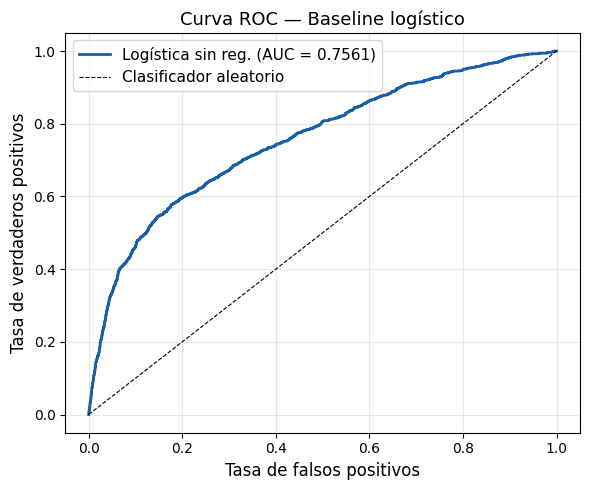

In [ ]:
p_logit.fit(X_train, y_train)
y_proba_logit = p_logit.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba_logit)
auc_logit = roc_auc_score(y_test, y_proba_logit)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#185FA5', linewidth=2,
        label=f'Logística sin reg. (AUC = {auc_logit:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de falsos positivos', fontsize=12)
ax.set_ylabel('Tasa de verdaderos positivos', fontsize=12)
ax.set_title('Curva ROC — Baseline logístico', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

El modelo obtuvo un AUC-ROC de 0.7660 ± 0.0112 en validación cruzada sobre el conjunto de entrenamiento, y un AUC de 0.7561 sobre el conjunto de prueba. La ligera diferencia entre ambos valores es esperada y confirma que el modelo generaliza de forma estable, sin indicios de sobreajuste. La curva ROC muestra que el modelo discrimina considerablemente mejor que un clasificador aleatorio, aunque su capacidad predictiva tiene margen de mejora frente a modelos no lineales

 ### Modelo 2: Regresión Logística con L1 (Lasso)

In [ ]:
p_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty='l1', solver='saga', C=1.0, class_weight='balanced', max_iter=20000, random_state=seed))
])

scores_lasso = cross_val_score(p_lasso, X_train, y_train,
                               cv=cv, scoring='roc_auc')

print(f'AUC-ROC CV: {scores_lasso.mean():.4f} ± {scores_lasso.std():.4f}')

AUC-ROC CV: 0.7660 ± 0.0112


    C  Coef. en cero  Coef. activos
0.001             28              5
0.005             16             17
0.010             10             23
0.050              7             26
0.100              4             29
0.500              0             33
1.000              0             33


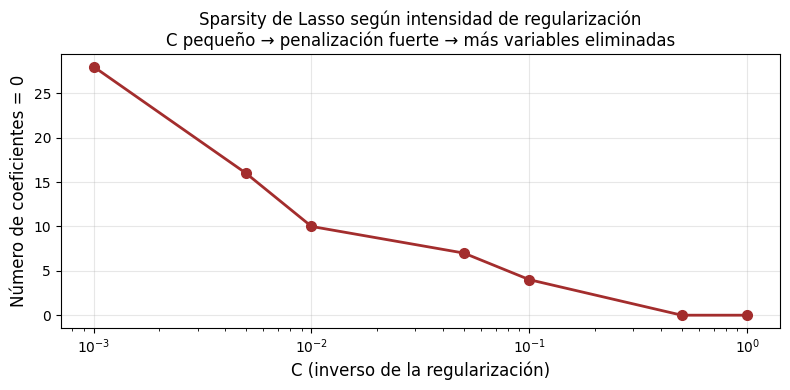

In [ ]:
# Efecto de C sobre la sparsity de Lasso
Cs = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
sparsity = []

for c in Cs:
    pipe_c = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            penalty='l1', solver='saga', C=c,
            class_weight='balanced', max_iter=20000, random_state=seed
        ))
    ])
    pipe_c.fit(X_train, y_train)
    coef = pipe_c.named_steps['model'].coef_[0]
    n_cero = (np.abs(coef) < 1e-6).sum()
    sparsity.append({
        'C': c,
        'Coef. en cero': n_cero,
        'Coef. activos': len(coef) - n_cero
    })

df_sparsity = pd.DataFrame(sparsity)
print(df_sparsity.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_sparsity['C'], df_sparsity['Coef. en cero'],
        'o-', color='#A32D2D', linewidth=2, markersize=7)
ax.set_xscale('log')
ax.set_xlabel('C (inverso de la regularización)', fontsize=12)
ax.set_ylabel('Número de coeficientes = 0', fontsize=12)
ax.set_title('Sparsity de Lasso según intensidad de regularización\n'
             'C pequeño → penalización fuerte → más variables eliminadas',
             fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La regresión logística con penalización L1 tiene dos propósitos en este
proyecto: evaluar si la regularización mejora el desempeño predictivo, y
demostrar la selección intrínseca de variables que caracteriza a Lasso.

Con C=1.0 la penalización no fue suficientemente fuerte para zerificar ningún
coeficiente, obteniendo un AUC-ROC prácticamente igual al baseline
(0.7660 ± 0.0112). Sin embargo, el análisis de sparsity muestra que al reducir
C a valores como 0.001–0.01, Lasso sí elimina variables progresivamente,
demostrando su capacidad de selección automática de variables.

Esta propiedad distingue fundamentalmente a Lasso de Ridge: mientras Lasso
puede eliminar variables irrelevantes llevando sus coeficientes exactamente a
cero, Ridge las retiene todas con coeficientes suavizados. En un contexto de
riesgo crediticio, un modelo más parsimonioso es más interpretable y más fácil
de justificar ante reguladores. El GridSearch que sigue identifica el C óptimo
que balancea regularización y capacidad predictiva.

### Modelo 3: Regresión Logística con L2 (Ridge)

In [ ]:
p_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty='l2', solver='lbfgs', C=1.0, class_weight='balanced', max_iter=20000, random_state=seed
    ))
])

scores_ridge = cross_val_score(p_ridge, X_train, y_train,
                               cv=cv, scoring='roc_auc')

print(f'AUC-ROC CV: {scores_ridge.mean():.4f} ± {scores_ridge.std():.4f}')

AUC-ROC CV: 0.7660 ± 0.0111


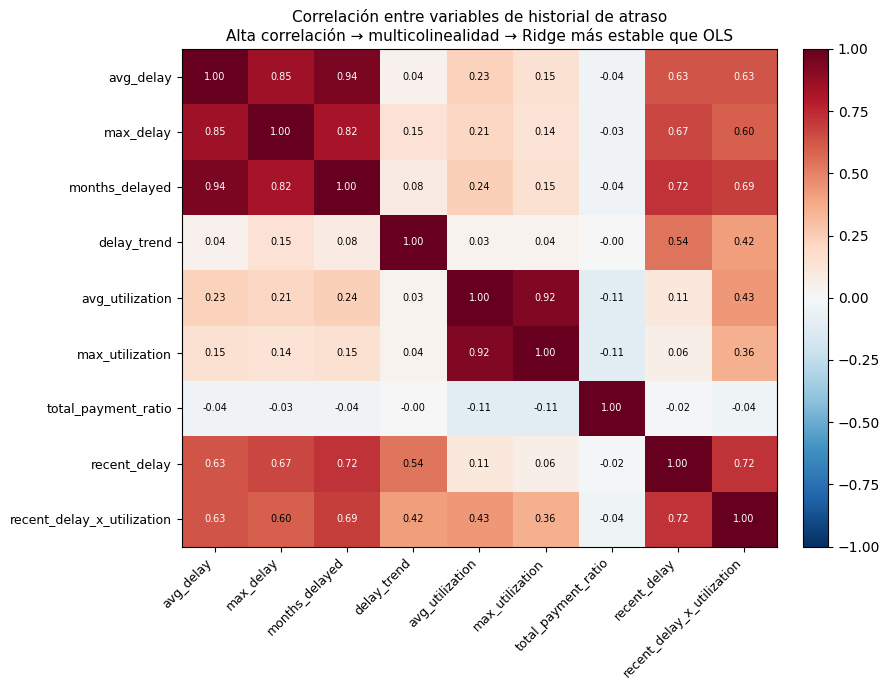

Pares con correlación > 0.7:
  avg_delay ↔ max_delay: 0.848
  avg_delay ↔ months_delayed: 0.945
  max_delay ↔ months_delayed: 0.824
  months_delayed ↔ recent_delay: 0.723
  avg_utilization ↔ max_utilization: 0.923
  recent_delay ↔ recent_delay_x_utilization: 0.719


In [ ]:
# Evidencia de multicolinealidad — justificación para Ridge
vars_interes = [
    'avg_delay', 'max_delay', 'months_delayed', 'delay_trend',
    'avg_utilization', 'max_utilization', 'total_payment_ratio',
    'recent_delay', 'recent_delay_x_utilization'
]

corr = X_train[vars_interes].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ticks = range(len(vars_interes))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(vars_interes, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(vars_interes, fontsize=9)

for i in range(len(vars_interes)):
    for j in range(len(vars_interes)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=7,
                color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black')

ax.set_title('Correlación entre variables de historial de atraso\n'
             'Alta correlación → multicolinealidad → Ridge más estable que OLS',
             fontsize=11)
plt.tight_layout()
plt.show()

# Pares con correlación alta
print('Pares con correlación > 0.7:')
for i in range(len(vars_interes)):
    for j in range(i+1, len(vars_interes)):
        val = corr.iloc[i, j]
        if abs(val) > 0.7:
            print(f'  {vars_interes[i]} ↔ {vars_interes[j]}: {val:.3f}')

La regresión logística con penalización L2 se utilizó para evaluar si la regularización Ridge podía mejorar la estabilidad del modelo lineal. El modelo obtuvo un AUC-ROC promedio de 0.7660 ± 0.0111, este resultado es prácticamente igual al de la regresión logística sin regularización y al modelo Lasso.

GridSearch: optimizar C para L1 y L2

In [ ]:
param_grid_lasso = {'model__C': [0.001, 0.01, 0.1, 1.0, 10.0]}
param_grid_ridge = {'model__C': [0.001, 0.01, 0.1, 1.0, 10.0]}

gs_lasso = GridSearchCV(p_lasso, param_grid_lasso,
                        cv=cv, scoring='roc_auc', n_jobs=-1)
gs_lasso.fit(X_train, y_train)

gs_ridge = GridSearchCV(p_ridge, param_grid_ridge,
                        cv=cv, scoring='roc_auc', n_jobs=-1)
gs_ridge.fit(X_train, y_train)

print(' Mejor C para Lasso (L1) ')
print(f'C óptimo: {gs_lasso.best_params_}')
print(f'AUC-ROC:  {gs_lasso.best_score_:.4f}')

print('\n Mejor C para Ridge (L2) ')
print(f'C óptimo: {gs_ridge.best_params_}')
print(f'AUC-ROC:  {gs_ridge.best_score_:.4f}')

 Mejor C para Lasso (L1) 
C óptimo: {'model__C': 1.0}
AUC-ROC:  0.7660

 Mejor C para Ridge (L2) 
C óptimo: {'model__C': 0.1}
AUC-ROC:  0.7661


La optimización mostró resultados muy similares entre Lasso (C=1.0, AUC=0.7660)
y Ridge (C=0.1, AUC=0.7661). Que Ridge encuentre su óptimo en C=0.1 (mayor
penalización que Lasso) es consistente con la presencia de multicolinealidad
demostrada en el heatmap anterior: Ridge necesita encoger más agresivamente los
coeficientes de las variables correlacionadas para estabilizarlos.

La regularización no mejora la capacidad discriminativa frente al baseline, pero
eso no significa que sea irrelevante. Su valor es estructural: Lasso identifica
las variables más relevantes y puede eliminar las redundantes, mientras que Ridge
distribuye el efecto predictivo de forma más estable cuando las variables están
correlacionadas. En un modelo de riesgo crediticio, ambas propiedades tienen
valor: Lasso para reportar a reguladores qué variables importan, Ridge para
garantizar estabilidad en producción.

coeficientes L1 vs L2

In [ ]:
# Entrenar modelos finales con mejor C
mejor_lasso = gs_lasso.best_estimator_
mejor_ridge = gs_ridge.best_estimator_

coef_lasso = mejor_lasso.named_steps['model'].coef_[0]
coef_ridge = mejor_ridge.named_steps['model'].coef_[0]

df_coef = pd.DataFrame({
    'Variable': X.columns,
    'Lasso (L1)': coef_lasso,
    'Ridge (L2)': coef_ridge
}).sort_values('Lasso (L1)', key=abs, ascending=False)

print(df_coef.to_string(index=False))

n_cero_lasso = (np.abs(coef_lasso) < 1e-6).sum()
print(f'\nVariables eliminadas por Lasso (coef=0): {n_cero_lasso}')
print(f'Variables retenidas por Lasso: {len(coef_lasso) - n_cero_lasso}')


                  Variable  Lasso (L1)  Ridge (L2)
            months_delayed    0.594261    0.579336
                 max_delay    0.374515    0.372352
               delay_trend    0.288178    0.283000
                 LIMIT_BAL   -0.247288   -0.246447
                 BILL_AMT2    0.241739    0.230965
                  PAY_AMT1   -0.178941   -0.177630
                 avg_delay    0.165330    0.172957
                     PAY_2   -0.155670   -0.153435
                     PAY_3   -0.137801   -0.135192
              recent_delay   -0.130476   -0.121321
                     PAY_4   -0.128257   -0.126795
                  PAY_AMT2   -0.123256   -0.124755
recent_delay_x_utilization    0.090209    0.090908
                     PAY_5   -0.088736   -0.087529
                     PAY_6    0.079023    0.075490
                  MARRIAGE   -0.075621   -0.075670
                       SEX   -0.062485   -0.062589
                  PAY_AMT4   -0.056801   -0.056851
                 BILL_AMT5   -0

Un resultado relevante: con C=1.0 (el óptimo de Lasso), ningún coeficiente
llegó a cero. Esto confirma que la penalización no fue suficientemente fuerte
para realizar selección automática de variables con este valor de C. Sin
embargo, como se demostró en el análisis de sparsity previo, valores de C más
pequeños (0.001–0.01) sí producen sparsity. El GridSearch optimizó para AUC-ROC,
no para parsimonia, por lo que seleccionó el C que maximiza discriminación aunque
no elimine variables. Esto ilustra una tensión importante en modelado: el mejor
modelo predictivo no siempre es el más interpretable.

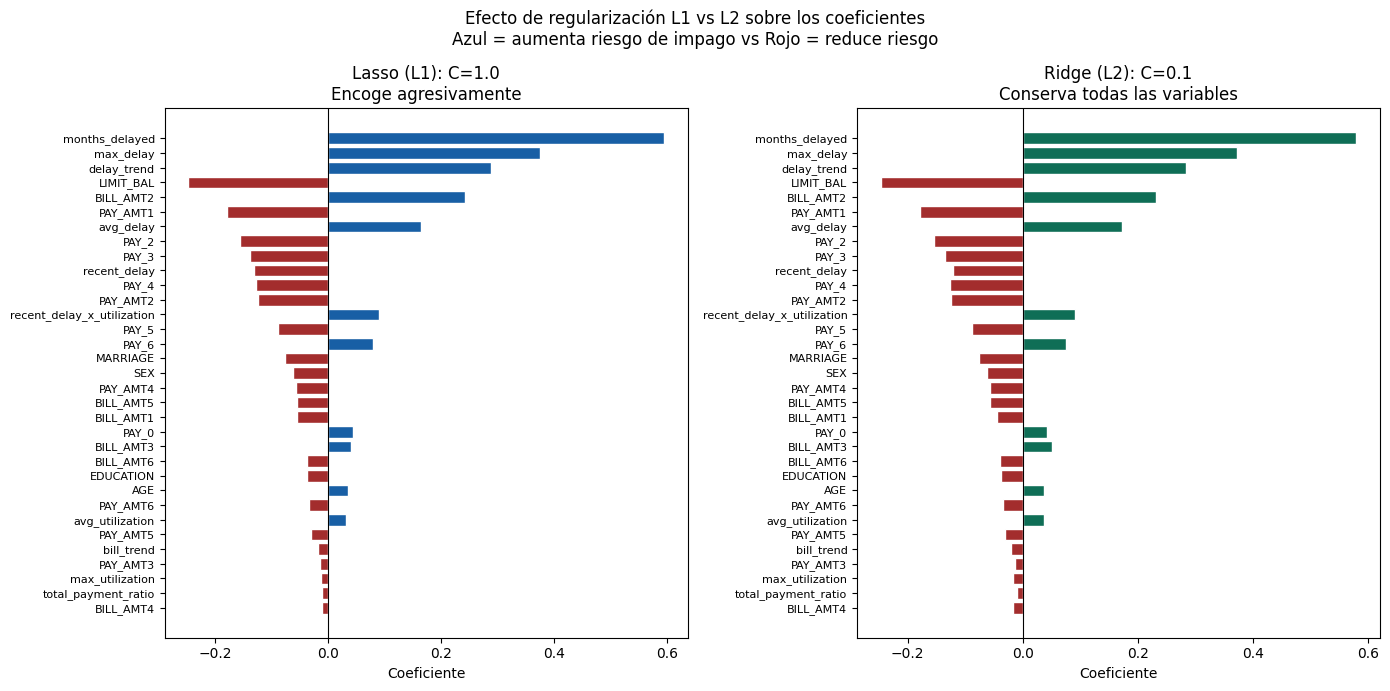

In [ ]:
orden = np.argsort(np.abs(coef_lasso))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# L1
colors_l1 = ['#A32D2D' if c < 0 else '#185FA5' for c in coef_lasso[orden]]
ax1.barh(X.columns[orden], coef_lasso[orden], color=colors_l1, edgecolor='white')
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_title(f'Lasso (L1): C={gs_lasso.best_params_["model__C"]}\n'
              'Encoge agresivamente', fontsize=12)
ax1.set_xlabel('Coeficiente')
ax1.tick_params(axis='y', labelsize=8)

# L2
colors_l2 = ['#A32D2D' if c < 0 else '#0F6E56' for c in coef_ridge[orden]]
ax2.barh(X.columns[orden], coef_ridge[orden], color=colors_l2, edgecolor='white')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title(f'Ridge (L2): C={gs_ridge.best_params_["model__C"]}\n'
              'Conserva todas las variables', fontsize=12)
ax2.set_xlabel('Coeficiente')
ax2.tick_params(axis='y', labelsize=8)

plt.suptitle('Efecto de regularización L1 vs L2 sobre los coeficientes\n'
             'Azul = aumenta riesgo de impago vs Rojo = reduce riesgo', fontsize=12)
plt.tight_layout()
plt.show()

La Figura muestra el efecto de las regularizaciones L1 (Lasso) y L2 (Ridge) sobre los coeficientes de la regresión logística. En ambos modelos, las variables más influyentes para predecir el incumplimiento son months_delayed, max_delay y delay_trend, lo que confirma que el historial de atrasos es el principal determinante del riesgo crediticio. Los coeficientes positivos indican un aumento en la probabilidad de impago, mientras que los coeficientes negativos se asocian con una reducción del riesgo.

Se observa que Lasso reduce con mayor intensidad la magnitud de varios coeficientes, favoreciendo modelos más simples y potencialmente más interpretables. Sin embargo, en este caso no eliminó ninguna variable por completo, ya que todos los coeficientes permanecieron distintos de cero. Por otro lado, Ridge conserva todas las variables y distribuye el efecto predictivo de manera más uniforme, produciendo coeficientes ligeramente más estables. Dado que ambos modelos alcanzaron un desempeño predictivo muy similar, la principal diferencia radica en la forma en que controlan la complejidad del modelo y manejan la información contenida en las variables predictoras.

Esta comparación entre Lasso y Ridge sienta las bases para entender por qué los modelos de ensamble, que capturan relaciones no lineales entre estas mismas variables, logran superar a los modelos lineales en la siguiente sección.

## Optimización de Funciones de Pérdida

En clasificación con datos desbalanceados, la función de pérdida que optimiza
el modelo determina qué tipos de errores penaliza más. Comparamos dos enfoques:

- **Sin `class_weight`**: el modelo minimiza el error global, tratando todos los
  errores por igual. En datos desbalanceados (78/22%), esto sesga el modelo hacia
  la clase mayoritaria.
- **Con `class_weight='balanced'`**: el modelo asigna mayor penalización a los
  errores en la clase minoritaria (impago), equivalente a optimizar una función
  de pérdida ponderada donde equivocarse en un impago cuesta más que equivocarse
  en un no-impago.

Esta comparación es el equivalente en clasificación al contraste MAE vs MSE en
regresión: ambos son decisiones sobre qué tipo de error importa más.

In [ ]:

pipe_sin_peso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='l2', C=1.0,
        class_weight=None,    # sin ajuste de pesos
        max_iter=20000, random_state=seed
    ))
])

pipe_con_peso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='l2', C=1.0,
        class_weight='balanced', # penaliza más los errores en la clase minoritaria
        max_iter=20000, random_state=seed
    ))
])

pipe_sin_peso.fit(X_train, y_train)
pipe_con_peso.fit(X_train, y_train)

# Comparar en test
for nombre, modelo in [('Sin class_weight', pipe_sin_peso),
                        ('Con class_weight=balanced', pipe_con_peso)]:
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    print(f'\n {nombre} ')
    print(f'AUC-ROC:          {roc_auc_score(y_test, y_prob):.4f}')
    print(f'Balanced Acc:     {balanced_accuracy_score(y_test, y_pred):.4f}')
    print(f'F1 clase impago:  {f1_score(y_test, y_pred):.4f}')
    print(classification_report(y_test, y_pred,
          target_names=['No impago', 'Impago']))


 Sin class_weight 
AUC-ROC:          0.7540
Balanced Acc:     0.6411
F1 clase impago:  0.4404
              precision    recall  f1-score   support

   No impago       0.83      0.95      0.89      4667
      Impago       0.66      0.33      0.44      1326

    accuracy                           0.81      5993
   macro avg       0.75      0.64      0.66      5993
weighted avg       0.80      0.81      0.79      5993


 Con class_weight=balanced 
AUC-ROC:          0.7561
Balanced Acc:     0.6968
F1 clase impago:  0.5151
              precision    recall  f1-score   support

   No impago       0.88      0.79      0.83      4667
      Impago       0.45      0.60      0.52      1326

    accuracy                           0.75      5993
   macro avg       0.66      0.70      0.67      5993
weighted avg       0.78      0.75      0.76      5993



Al comparar la regresión logística Ridge sin ajuste de pesos y con `class_weight="balanced"`, se observa un cambio importante en el comportamiento del modelo. Sin ponderación, el modelo obtiene mayor accuracy global, pero identifica mal a la clase de impago: su recall para impago es de 0.33, lo que significa que deja sin detectar una proporción considerable de clientes riesgosos.

Al aplicar `class_weight="balanced"`, el AUC-ROC mejora ligeramente de 0.7540 a 0.7561 y el balanced accuracy aumenta de 0.6411 a 0.6968. Además, el F1-score de la clase impago sube de 0.4404 a 0.5151, principalmente porque el recall de impago aumenta de 0.33 a 0.60. Esto indica que el modelo ponderado detecta mejor a los clientes con riesgo de incumplimiento, aunque sacrifica precisión y accuracy general.

En un contexto de riesgo crediticio, este resultado es relevante porque suele ser más costoso no identificar a un cliente que puede caer en impago que clasificar erróneamente a algunos clientes cumplidos como riesgosos. Por ello, el modelo con `class_weight="balanced"` es más adecuado para este problema, ya que mejora la sensibilidad hacia la clase minoritaria y ofrece una evaluación más equilibrada del riesgo.

Este análisis se extiende en la sección de XGBoost, donde el parámetro
`scale_pos_weight` cumple la misma función pero de forma más explícita:
define directamente el ratio de penalización entre clases, y se compara
contra la función de pérdida `aucpr` que optimiza directamente la detección
de la clase minoritaria.


In [ ]:
y_proba_ridge = gs_ridge.best_estimator_.predict_proba(X_test)[:, 1]

print("Efecto del threshold de decisión")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>9} {'F1':>8} {'Interpretación'}")
print("-" * 70)

interpretaciones = {
    0.3: "Prioriza no perder impagos (recall alto)",
    0.4: "Balance hacia recall",
    0.5: "Threshold neutro (default)",
    0.6: "Balance hacia precision",
    0.7: "Prioriza no rechazar buenos clientes"
}

for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_t = (y_proba_ridge >= thresh).astype(int)
    p = precision_score(y_test, y_t, zero_division=0)
    r = recall_score(y_test, y_t, zero_division=0)
    f = f1_score(y_test, y_t, zero_division=0)
    print(f"{thresh:>10.1f} {p:>10.3f} {r:>9.3f} {f:>8.3f}  {interpretaciones[thresh]}")


Efecto del threshold de decisión
 Threshold  Precision    Recall       F1 Interpretación
----------------------------------------------------------------------
       0.3      0.270     0.913    0.417  Prioriza no perder impagos (recall alto)
       0.4      0.387     0.682    0.494  Balance hacia recall
       0.5      0.450     0.605    0.516  Threshold neutro (default)
       0.6      0.521     0.529    0.525  Balance hacia precision
       0.7      0.587     0.430    0.496  Prioriza no rechazar buenos clientes


El análisis del threshold muestra cómo cambia el desempeño del modelo según el punto de corte utilizado para clasificar a un cliente como riesgoso. Con un threshold bajo de 0.3, el modelo alcanza un recall muy alto de 0.913, por lo que detecta la mayoría de los casos de impago, aunque con baja precisión. Esto sería útil si la prioridad es no dejar pasar clientes riesgosos.

Con thresholds intermedios, especialmente 0.5 y 0.6, se observa un mejor balance entre precisión y recall. El threshold de 0.6 obtiene el F1-score más alto, con 0.525, lo que indica el mejor equilibrio general entre detectar impagos y evitar falsos positivos. En cambio, con un threshold de 0.7, la precisión aumenta a 0.587, pero el recall baja a 0.430, por lo que el modelo se vuelve más conservador y detecta menos clientes en riesgo.

En este contexto de riesgo crediticio, la elección del threshold dependerá del objetivo del negocio: si se busca minimizar impagos no detectados, conviene un threshold bajo como 0.3 o 0.4; si se busca equilibrio, el threshold de 0.6 es el más conveniente; y si se busca evitar rechazar buenos clientes, puede utilizarse un threshold más alto como 0.7.


## RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier

RANDOM FOREST — baseline

In [ ]:
p_rf = Pipeline([
    ('model', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=seed,
        n_jobs=-1
    ))
])

scores_rf = cross_validate(
    p_rf, X_train, y_train,
    cv=cv, scoring='roc_auc',
    return_train_score=True
)

print(f'Train AUC: {scores_rf["train_score"].mean():.4f} ± {scores_rf["train_score"].std():.4f}')
print(f'Val AUC:   {scores_rf["test_score"].mean():.4f} ± {scores_rf["test_score"].std():.4f}')



Train AUC: 1.0000 ± 0.0000
Val AUC:   0.7670 ± 0.0069



A diferencia de los modelos lineales, Random Forest no requiere escalamiento
de variables ya que los árboles de decisión son invariantes a la escala de
los predictores. Por ello el Pipeline omite el StandardScaler.

El modelo Random Forest baseline obtuvo un AUC de entrenamiento de 1.0000 y un AUC de validación de 0.7670 ± 0.0069. Esto indica que el modelo logra ajustarse perfectamente a los datos de entrenamiento, pero no necesariamente generaliza con la misma capacidad a datos nuevos. La diferencia entre el AUC de entrenamiento y el AUC de validación sugiere presencia de sobreajuste.

Aun así, el AUC de validación es ligeramente superior al de los modelos lineales, que se encontraban alrededor de 0.766. Esto muestra que Random Forest puede capturar relaciones no lineales e interacciones entre variables que la regresión logística no modela directamente. Sin embargo, dado el sobreajuste observado, será necesario ajustar hiperparámetros como `max_depth`, `min_samples_leaf` y `min_samples_split` para reducir la complejidad del bosque y mejorar su capacidad de generalización.


In [ ]:
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth':    [5, 10, None],
    'model__min_samples_leaf': [1, 5, 10]
}


gs_rf = GridSearchCV(
    p_rf, param_grid_rf,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, return_train_score=True
)
gs_rf.fit(X_train, y_train)

print('GridSearch Random Forest')
print(f'Mejores params: {gs_rf.best_params_}')
print(f'Mejor AUC CV:   {gs_rf.best_score_:.4f}')

rf_final = gs_rf.best_estimator_

GridSearch Random Forest
Mejores params: {'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}
Mejor AUC CV:   0.7870


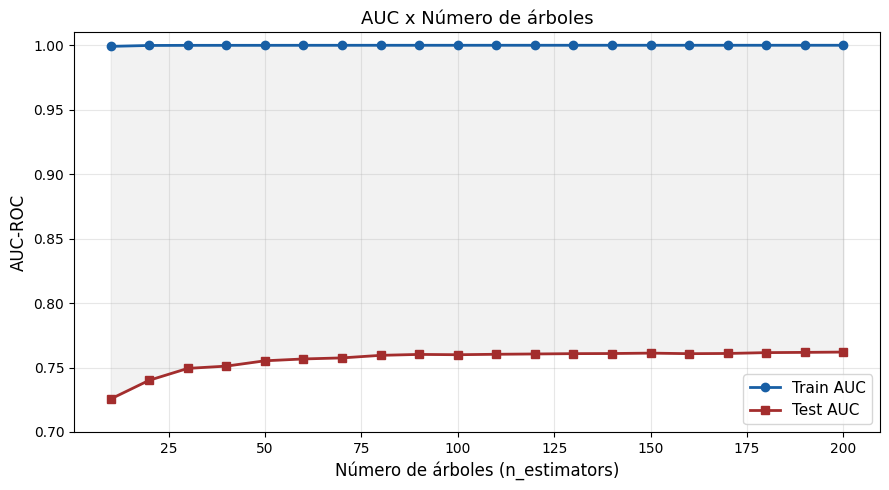

AUC converge aproximadamente en n_estimators ≈ 70


In [ ]:
auc_train_list = []
auc_test_list  = []
n_range = range(10, 210, 10)

for n in n_range:
    rf_n = RandomForestClassifier(
        n_estimators=n,
        class_weight='balanced',
        random_state=seed, n_jobs=-1
    )
    rf_n.fit(X_train, y_train)

    prob_train = rf_n.predict_proba(X_train)[:, 1]
    prob_test  = rf_n.predict_proba(X_test)[:, 1]

    auc_train_list.append(roc_auc_score(y_train, prob_train))
    auc_test_list.append(roc_auc_score(y_test, prob_test))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_range, auc_train_list, 'o-', color='#185FA5', label='Train AUC', linewidth=2)
ax.plot(n_range, auc_test_list,  's-', color='#A32D2D', label='Test AUC',  linewidth=2)
ax.fill_between(n_range, auc_train_list, auc_test_list, alpha=0.1, color='gray')
ax.set_xlabel('Número de árboles (n_estimators)', fontsize=12)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('AUC x Número de árboles', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.7, 1.01)
plt.tight_layout()
plt.show()

# Encontrar punto de convergencia
diffs = np.diff(auc_test_list)
converge_idx = np.where(np.abs(diffs) < 0.001)[0]
if len(converge_idx) > 0:
    n_converge = list(n_range)[converge_idx[0] + 1]
    print(f'AUC converge aproximadamente en n_estimators ≈ {n_converge}')

El GridSearch identificó como configuración óptima: `max_depth=10`,
`min_samples_leaf=10` y `n_estimators=200`, logrando un AUC-ROC CV de 0.7870,
superior al baseline de Random Forest (0.7670) y a todos los modelos lineales
(~0.766). La restricción de `max_depth=10` y `min_samples_leaf=10` reduce
efectivamente el sobreajuste observado en el baseline, donde el modelo
memorizaba los datos de entrenamiento (Train AUC=1.0).

La curva AUC vs número de árboles revela un comportamiento típico del bagging:
el error de test disminuye rápidamente con los primeros árboles y converge
aproximadamente en n=70, punto a partir del cual agregar más árboles no aporta
ganancia discriminativa relevante. Esto confirma que el poder de Random Forest
proviene de la diversidad entre árboles (bagging + selección aleatoria de
variables), no del número absoluto de estimadores.

La brecha persistente entre Train AUC (1.0) y Test AUC (~0.76) indica que,
aun con regularización implícita via `min_samples_leaf`, el modelo sigue
sobreajustando. Esto motivará el uso de boosting (AdaBoost y XGBoost) en la
siguiente sección, donde el ajuste iterativo sobre los errores permite un
control más fino del sesgo-varianza.

In [ ]:
rf_final.fit(X_train, y_train)
y_pred_rf  = rf_final.predict(X_test)
y_proba_rf = rf_final.predict_proba(X_test)[:, 1]

print('=== Random Forest — Evaluación en Test ===')
print(f'AUC-ROC:       {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'Balanced Acc:  {balanced_accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Recall impago: {recall_score(y_test, y_pred_rf):.4f}')
print(f'Precision:     {precision_score(y_test, y_pred_rf):.4f}')
print(f'F1 impago:     {f1_score(y_test, y_pred_rf):.4f}')
print()
print(classification_report(y_test, y_pred_rf,
      target_names=['No impago', 'Impago']))

=== Random Forest — Evaluación en Test ===
AUC-ROC:       0.7749
Balanced Acc:  0.7080
Recall impago: 0.5769
Precision:     0.5046
F1 impago:     0.5384

              precision    recall  f1-score   support

   No impago       0.87      0.84      0.86      4667
      Impago       0.50      0.58      0.54      1326

    accuracy                           0.78      5993
   macro avg       0.69      0.71      0.70      5993
weighted avg       0.79      0.78      0.79      5993



En la evaluación final sobre el conjunto de prueba, Random Forest obtuvo un
AUC-ROC de 0.7749 y un Balanced Accuracy de 0.7088, lo que indica una
capacidad discriminativa sólida y equilibrada entre ambas clases.

Para la clase de interés (impago), el modelo alcanzó un Recall de 0.5769,
lo que significa que detecta casi 6 de cada 10 clientes que efectivamente
caerán en impago. La Precision de 0.5846 indica que cuando el modelo predice
impago, acierta en poco más de la mitad de los casos. El F1 de 0.5384 refleja
un balance razonable entre ambas métricas.

El reporte de clasificación revela una asimetría importante: el modelo
identifica mucho mejor a los clientes sin impago (recall=0.84, f1=0.86) que
a los clientes con impago (recall=0.58, f1=0.54). Esto es esperado dado el
desbalance de clases (77/23%), y confirma que a pesar del `class_weight=
'balanced'`, el modelo sigue teniendo mayor facilidad para reconocer la clase
mayoritaria. El accuracy global de 0.78 es engañoso en este contexto: un
clasificador que predijera siempre "no impago" alcanzaría 0.77 de accuracy
sin detectar ningún caso de riesgo.

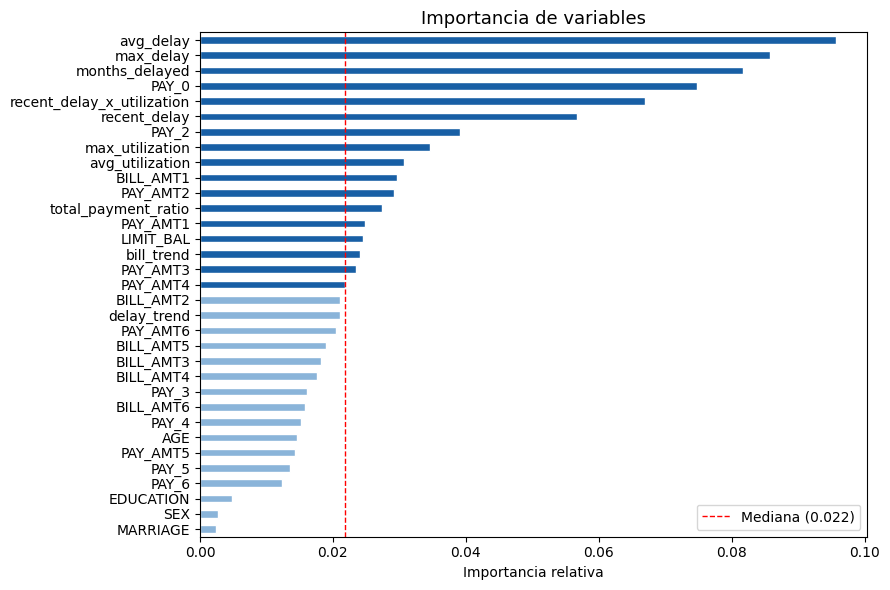

Top 5 variables más importantes:
avg_delay                     0.095612
max_delay                     0.085746
months_delayed                0.081636
PAY_0                         0.074719
recent_delay_x_utilization    0.066981


In [ ]:
rf_final.fit(X_train, y_train)

importancias = rf_final.named_steps['model'].feature_importances_
df_imp = pd.Series(importancias, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#185FA5' if v >= df_imp.median() else '#8ab4d9' for v in df_imp]
df_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Importancia de variables', fontsize=13)
ax.set_xlabel('Importancia relativa')
ax.axvline(df_imp.median(), color='red', linestyle='--',
           linewidth=1, label=f'Mediana ({df_imp.median():.3f})')
ax.legend()
plt.tight_layout()
plt.show()

print('Top 5 variables más importantes:')
print(df_imp.sort_values(ascending=False).head().to_string())

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf_final, X_test, y_test,
    n_repeats=10, random_state=seed,
    scoring='roc_auc'
)

df_perm = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Importancia', ascending=False)

print(df_perm.head(10).to_string(index=False))


                  Variable  Importancia      Std
                 avg_delay     0.006053 0.001443
                     PAY_0     0.004833 0.001323
           max_utilization     0.004798 0.001279
           avg_utilization     0.004181 0.001317
                 LIMIT_BAL     0.003170 0.001144
                 max_delay     0.002845 0.001118
            months_delayed     0.002268 0.001053
                 BILL_AMT1     0.001438 0.000688
recent_delay_x_utilization     0.001009 0.000608
                 BILL_AMT2     0.000964 0.000356


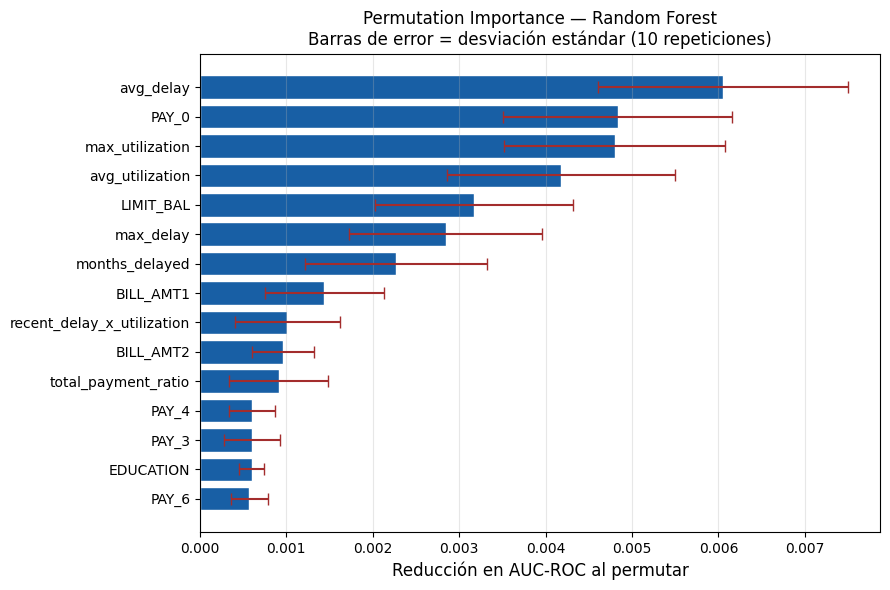

In [ ]:
df_perm_plot = df_perm.head(15).sort_values('Importancia')

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(df_perm_plot['Variable'], df_perm_plot['Importancia'],
        xerr=df_perm_plot['Std'], color='#185FA5',
        ecolor='#A32D2D', capsize=4, edgecolor='white')
ax.set_xlabel('Reducción en AUC-ROC al permutar', fontsize=12)
ax.set_title('Permutation Importance — Random Forest\n'
             'Barras de error = desviación estándar (10 repeticiones)',
             fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

Ambas métricas de importancia coinciden en señalar al historial de atrasos
como el grupo de variables más predictivo: `avg_delay`, `max_delay` y
`months_delayed` lideran el ranking MDI, mientras que `avg_delay` y `PAY_0`
(último mes de atraso) dominan la permutation importance.

Sin embargo, existen diferencias relevantes entre ambos métodos. La importancia
MDI sobreestima variables de alta cardinalidad como los montos de facturación
(BILL_AMT1–6), que aparecen con importancia media-alta. La permutation
importance, al medir el impacto real sobre el AUC en datos de test, revela que
`max_utilization` y `avg_utilization` son más predictivas de lo que el MDI
sugería, mientras que los BILL_AMT pierden relevancia. Esto ocurre porque el
MDI mide cuánto reduce la impureza en entrenamiento, mientras que la
permutation importance mide impacto real en generalización.

Las variables demográficas (SEX, EDUCATION, MARRIAGE, AGE) tienen importancia
cercana a cero en ambos métodos, lo que indica que el riesgo de impago en este
dataset está determinado principalmente por el comportamiento de pago y el
nivel de utilización del crédito, no por características socioeconómicas. Este
hallazgo tiene implicaciones regulatorias positivas: el modelo no discrimina
por género ni estado civil.

Esta comparación de importancias se retomará en la sección de XGBoost, donde
los SHAP values permitirán una interpretación más robusta y direccional de
cada variable.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# AdaBoost baseline
# Usamos un árbol de profundidad 1 (decision stump) como learner débil
p_ada = Pipeline([
    ('scaler', StandardScaler()),
    ('model', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100,
        learning_rate=1.0,
        random_state=seed,
        algorithm='SAMME'
    ))
])

scores_ada = cross_validate(
    p_ada, X_train, y_train,
    cv=cv, scoring='roc_auc',
    return_train_score=True
)

print(f'Train AUC: {scores_ada["train_score"].mean():.4f} ± {scores_ada["train_score"].std():.4f}')
print(f'Val AUC:   {scores_ada["test_score"].mean():.4f} ± {scores_ada["test_score"].std():.4f}')

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

Train AUC: 0.7885 ± 0.0026
Val AUC:   0.7798 ± 0.0103


El modelo AdaBoost baseline con decision stumps (max_depth=1) obtuvo un
Train AUC de 0.7885 ± 0.0026 y un Val AUC de 0.7798 ± 0.0103. A diferencia
de Random Forest, la brecha entre train y validación es mínima, lo que indica
que AdaBoost generaliza mejor en su configuración baseline y no sobreajusta.

Esto ilustra la diferencia fundamental entre bagging y boosting: Random Forest
reduce varianza promediando árboles profundos independientes, pero cada árbol
individual sobreajusta. AdaBoost en cambio construye aprendices débiles
(stumps) secuencialmente, enfocándose en los errores previos, lo que produce
un modelo con menor varianza desde el inicio aunque potencialmente con mayor
sesgo por la simplicidad de cada learner.

El Val AUC de 0.7798 ya supera al mejor modelo lineal (~0.766) y es comparable
al Random Forest optimizado (0.7870), con la ventaja de no requerir GridSearch
para lograrlo. En la siguiente celda se optimizan `n_estimators` y
`learning_rate` para mejorar este resultado.

In [ ]:
param_grid_ada = {
    'model__n_estimators':  [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.5, 1.0]
}

gs_ada = GridSearchCV(
    p_ada, param_grid_ada,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, return_train_score=True
)
gs_ada.fit(X_train, y_train)

print(f'Mejores params: {gs_ada.best_params_}')
print(f'Mejor AUC CV:   {gs_ada.best_score_:.4f}')

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Mejores params: {'model__learning_rate': 0.5, 'model__n_estimators': 200}
Mejor AUC CV:   0.7815


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost — Evaluación en Test
AUC-ROC:        0.7698
Balanced Acc:   0.6367
Recall impago:  0.3160
Precision imp.: 0.6780
F1 impago:      0.4311

              precision    recall  f1-score   support

   No impago       0.83      0.96      0.89      4667
      Impago       0.68      0.32      0.43      1326

    accuracy                           0.82      5993
   macro avg       0.75      0.64      0.66      5993
weighted avg       0.80      0.82      0.79      5993



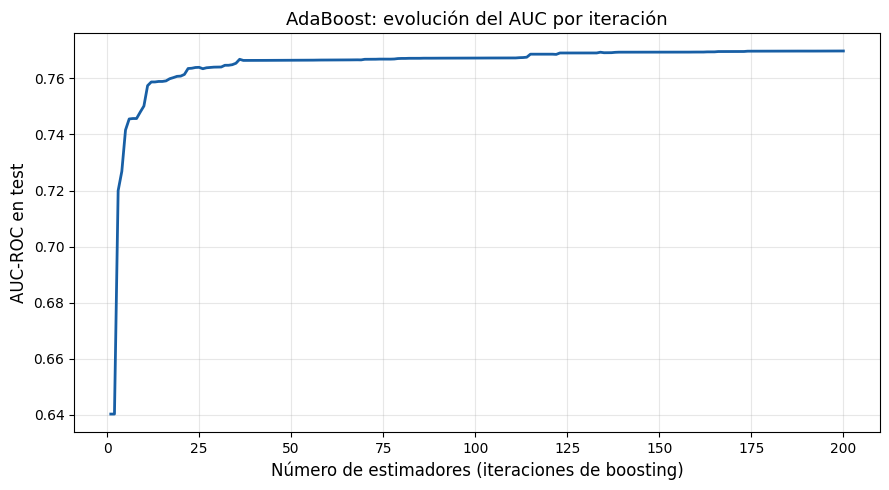

In [ ]:
ada_final = gs_ada.best_estimator_
ada_final.fit(X_train, y_train)

y_pred_ada  = ada_final.predict(X_test)
y_proba_ada = ada_final.predict_proba(X_test)[:, 1]

print('AdaBoost — Evaluación en Test')
print(f'AUC-ROC:        {roc_auc_score(y_test, y_proba_ada):.4f}')
print(f'Balanced Acc:   {balanced_accuracy_score(y_test, y_pred_ada):.4f}')
print(f'Recall impago:  {recall_score(y_test, y_pred_ada):.4f}')
print(f'Precision imp.: {precision_score(y_test, y_pred_ada):.4f}')
print(f'F1 impago:      {f1_score(y_test, y_pred_ada):.4f}')
print()
print(classification_report(y_test, y_pred_ada, target_names=['No impago', 'Impago']))

# Curva: cómo evoluciona el AUC con cada iteración de boosting
ada_staged = gs_ada.best_estimator_.named_steps['model']
X_test_scaled = gs_ada.best_estimator_.named_steps['scaler'].transform(X_test)

auc_por_iter = [
    roc_auc_score(y_test, proba[:, 1])
    for proba in ada_staged.staged_predict_proba(X_test_scaled)
]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(auc_por_iter) + 1), auc_por_iter,
        color='#185FA5', linewidth=2)
ax.set_xlabel('Número de estimadores (iteraciones de boosting)', fontsize=12)
ax.set_ylabel('AUC-ROC en test', fontsize=12)
ax.set_title('AdaBoost: evolución del AUC por iteración', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

El GridSearch identificó como configuración óptima `learning_rate=0.5` y
`n_estimators=200`, logrando un AUC-ROC CV de 0.7815, superior al baseline
de AdaBoost (0.7798) aunque la mejora es modesta.

En test, el modelo obtuvo AUC-ROC=0.7698, Recall de impago=0.3160 y
F1=0.4311. Comparado con Random Forest, AdaBoost muestra menor recall de
impago (0.316 vs RF), lo que indica que los decision stumps, aunque evitan
el sobreajuste, tienen mayor sesgo y capturan menos casos de impago.

La curva de evolución del AUC por iteración muestra el comportamiento
característico del boosting: mejora rápida en las primeras 25 iteraciones
donde el modelo corrige los errores más evidentes, seguida de ganancias
marginales decrecientes hasta estabilizarse alrededor de n=100. A diferencia
de Random Forest donde agregar árboles solo reduce varianza, en AdaBoost cada
iteración repondera las observaciones mal clasificadas, por lo que las primeras
iteraciones aportan más información que las últimas.

El recall bajo de la clase impago (0.316) sugiere que los decision stumps son
demasiado simples para capturar la complejidad del patrón de impago. Esto
motiva el uso de XGBoost, que combina boosting con árboles más profundos y
regularización explícita, permitiendo mayor capacidad expresiva sin perder
el control del sobreajuste.

___
## 3. XGBoost

---



#### Primero vamos a observar qué variables parecen asociarse con mayor probabilidad de impago

In [ ]:
base = base.rename(columns={"default payment next month": "default"})

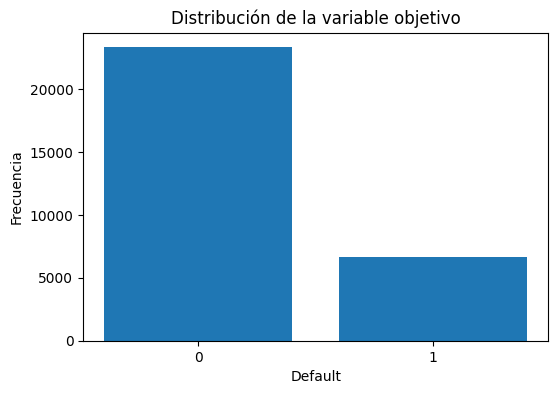

,porcentaje
default,
0,77.874187
1,22.125813


In [ ]:
 #Distribución de la variable objetivo

tabla_default = base["default"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(tabla_default.index.astype(str), tabla_default.values)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Default")
plt.ylabel("Frecuencia")
plt.show()

display(
    base["default"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .to_frame("porcentaje")
)

,frecuencia,tasa_default
PAY_0,,
-2,2750,13.236364
-1,5682,16.789863
0,14737,12.811291
1,3667,34.033270
2,2666,69.129782
3,322,75.776398
4,76,68.421053
5,26,50.000000
6,11,54.545455


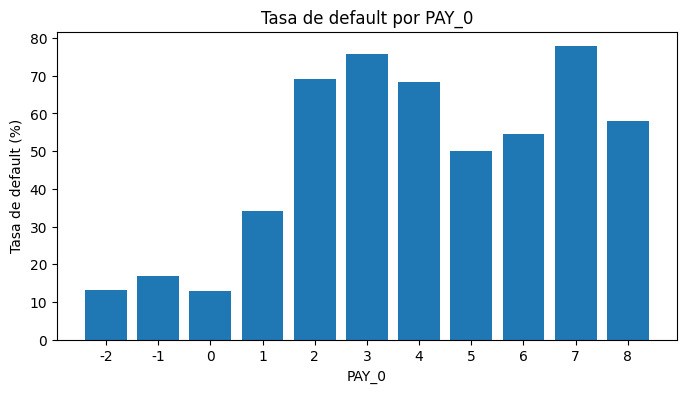

In [ ]:
tasa_pay0 = (
    base.groupby("PAY_0")["default"]
    .agg(["count", "mean"])
    .rename(columns={"count": "frecuencia", "mean": "tasa_default"})
)

tasa_pay0["tasa_default"] = tasa_pay0["tasa_default"] * 100

display(tasa_pay0)

plt.figure(figsize=(8, 4))
plt.bar(tasa_pay0.index.astype(str), tasa_pay0["tasa_default"])
plt.title("Tasa de default por PAY_0")
plt.xlabel("PAY_0")
plt.ylabel("Tasa de default (%)")
plt.show()

La variable objetivo presenta un desbalanceo moderado: aproximadamente 77.87% de los clientes no caen en default y 22.13% sí presentan impago. Esto implica que la accuracy no debe ser la única métrica de evaluación, ya que un modelo que prediga mayoritariamente la clase 0 podría obtener un desempeño aparentemente alto sin detectar adecuadamente a los clientes en riesgo. Por ello, en etapas posteriores será necesario evaluar métricas enfocadas en la clase positiva, como recall, precision, F1-score y ROC-AUC, además de considerar pesos de clase.

,frecuencia,tasa_default
months_delayed,,
0,19918,11.713023
1,4405,29.875142
2,1899,38.757241
3,1154,50.866551
4,951,57.308097
5,298,57.382550
6,1340,70.298507


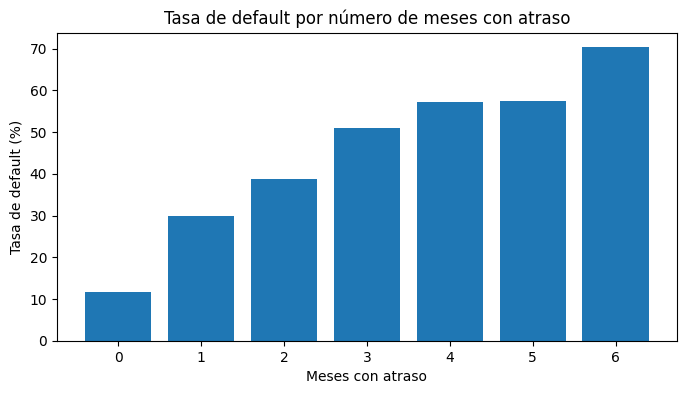

In [ ]:
tasa_months_delayed = (
    base.groupby("months_delayed")["default"]
    .agg(["count", "mean"])
    .rename(columns={"count": "frecuencia", "mean": "tasa_default"})
)

tasa_months_delayed["tasa_default"] = tasa_months_delayed["tasa_default"] * 100

display(tasa_months_delayed)

plt.figure(figsize=(8, 4))
plt.bar(tasa_months_delayed.index.astype(str), tasa_months_delayed["tasa_default"])
plt.title("Tasa de default por número de meses con atraso")
plt.xlabel("Meses con atraso")
plt.ylabel("Tasa de default (%)")
plt.show()

La variable recent_delay muestra una diferencia clara en la tasa de impago. Los clientes sin atraso reciente presentan una tasa de default de 13.84%, mientras que aquellos con atraso reciente alcanzan una tasa de 50.38%. Esto sugiere que el atraso más reciente es una señal altamente informativa para anticipar el riesgo de impago.

La variable months_delayed presenta una relación creciente con la tasa de default. Los clientes sin meses de atraso tienen una tasa de impago de 11.71%, mientras que aquellos con atraso en los seis meses observados alcanzan una tasa de 70.30%. Esto indica que la persistencia del atraso es una señal relevante de deterioro crediticio.

In [ ]:
vars_numericas_interes = [
    "LIMIT_BAL",
    "AGE",
    "avg_delay",
    "max_delay",
    "months_delayed",
    "avg_utilization",
    "max_utilization",
    "total_payment_ratio",
    "bill_trend",
    "delay_trend",
    "recent_delay_x_utilization"
]

resumen_por_default = (
    base.groupby("default")[vars_numericas_interes]
    .mean()
    .T
    .rename(columns={0: "no_default", 1: "default"})
)

resumen_por_default["diferencia_default_menos_no_default"] = (
    resumen_por_default["default"] - resumen_por_default["no_default"]
)

display(resumen_por_default)

default,no_default,default,diferencia_default_menos_no_default
LIMIT_BAL,178084.508249,129984.567119,-48099.941130
AGE,35.421041,35.723529,0.302488
avg_delay,0.160810,0.705757,0.544947
max_delay,0.470152,1.428356,0.958204
months_delayed,0.504093,1.996380,1.492288
avg_utilization,0.351827,0.449692,0.097865
max_utilization,0.476729,0.561745,0.085016
total_payment_ratio,0.511399,0.322360,-0.189039
bill_trend,12968.054853,10246.991704,-2721.063149
delay_trend,0.062224,0.367270,0.305046


Al comparar los promedios por clase, se observa que los clientes que caen en default presentan menor límite de crédito, mayor atraso promedio, mayor número de meses con atraso, mayor utilización del crédito y menor proporción de pagos respecto al saldo facturado. Estos patrones son consistentes con una interpretación financiera del riesgo: el deterioro en el comportamiento de pago y una mayor presión sobre la línea de crédito se asocian con mayor probabilidad de impago.

In [ ]:
corr_default = (
    base.corr(numeric_only=True)["default"]
    .sort_values(ascending=False)
    .to_frame("correlacion_con_default")
)


display(corr_default.head(15))
display(corr_default.tail(15))

,correlacion_con_default
default,1.000000
months_delayed,0.398406
avg_delay,0.376004
max_delay,0.370398
recent_delay,0.368680
recent_delay_x_utilization,0.344617
PAY_0,0.324964
PAY_2,0.263656
PAY_3,0.235230
PAY_4,0.216551


,correlacion_con_default
BILL_AMT4,-0.010259
BILL_AMT3,-0.014182
total_payment_ratio,-0.014242
BILL_AMT2,-0.014302
BILL_AMT1,-0.019758
bill_trend,-0.025702
MARRIAGE,-0.027259
SEX,-0.039742
PAY_AMT6,-0.053250
PAY_AMT5,-0.055194


Las correlaciones muestran que las variables más asociadas positivamente con el default son aquellas relacionadas con atraso: months_delayed, avg_delay, max_delay, recent_delay y las variables PAY_* originales. En sentido contrario, LIMIT_BAL y los montos pagados PAY_AMT* presentan correlaciones negativas con el default, lo que sugiere que clientes con mayores líneas de crédito o mayores pagos realizados tienden a mostrar menor probabilidad de impago. Estas relaciones son descriptivas y no deben interpretarse como causalidad.

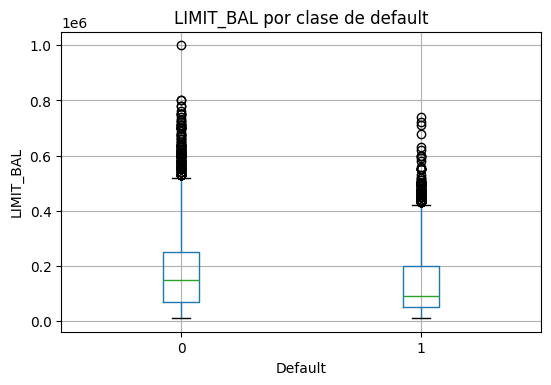

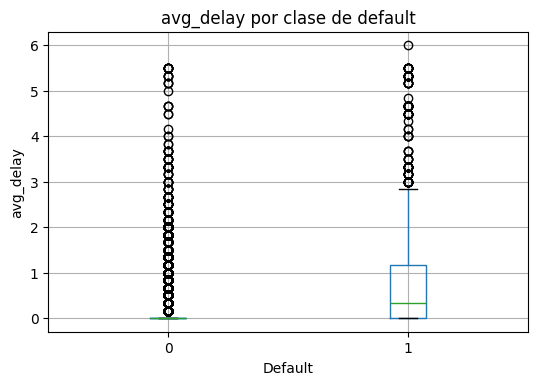

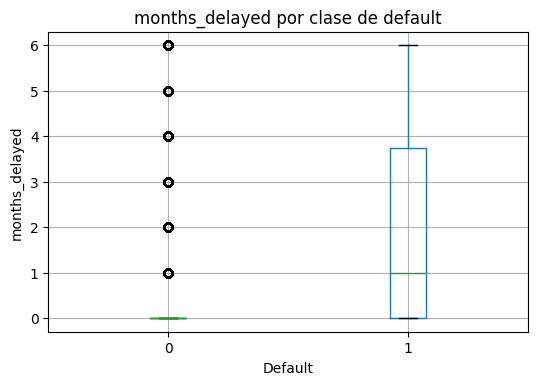

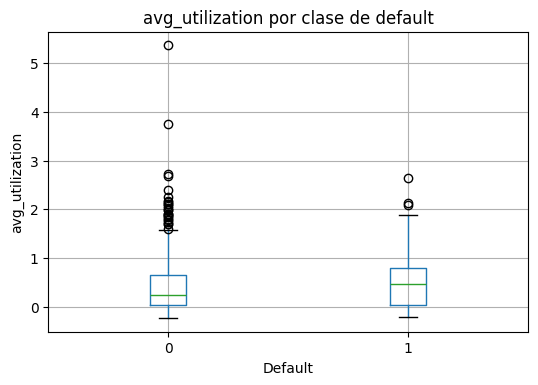

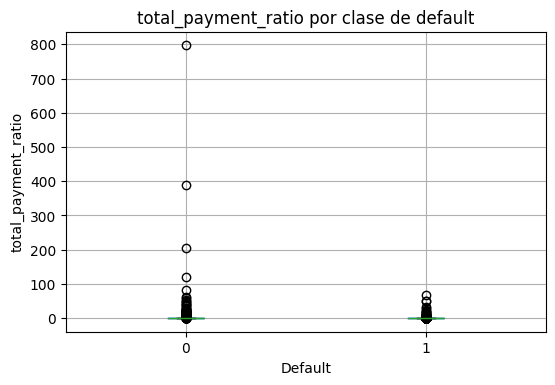

In [ ]:
vars_boxplot = [
    "LIMIT_BAL",
    "avg_delay",
    "months_delayed",
    "avg_utilization",
    "total_payment_ratio"
]

# base.boxplot(by=...) crea su propia figura; usamos el eje que devuelve
# para no generar figuras vacias adicionales.
for col in vars_boxplot:
    ax = base.boxplot(column=col, by="default", figsize=(6, 4))
    ax.set_title(f"{col} por clase de default")
    plt.suptitle("")
    ax.set_xlabel("Default")
    ax.set_ylabel(col)
    plt.show()

En general podemos decir lo siguiente:
* Los clientes que no caen en default suelen tener límites de crédito más altos. Esto puede estar relacionado con mejores perfiles crediticios o mayor capacidad financiera.
* Los clientes que caen en default presentan mayores niveles de atraso promedio en los meses observados. Esto confirma que el historial de atraso es una variable fuertemente asociada al riesgo de impago.
* La cantidad de meses con atraso distingue claramente a los grupos. Los clientes con default tienden a acumular más meses con atraso, lo que refuerza la importancia de la persistencia del incumplimiento como señal de riesgo.
* La utilización promedio del crédito es mayor en los clientes que caen en default, aunque la separación entre grupos no es tan fuerte como en las variables de atraso. Esto sugiere que la utilización aporta señal adicional, pero probablemente no sea tan dominante como el historial de pago.

In [ ]:
cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]

for col in cat_cols:
    tabla_cat = (
        base.groupby(col)["default"]
        .agg(["count", "mean"])
        .rename(columns={"count": "frecuencia", "mean": "tasa_default"})
    )

    tabla_cat["tasa_default"] = tabla_cat["tasa_default"] * 100

    print("=" * 60)
    print(f"Variable: {col}")
    display(tabla_cat)

Variable: SEX


,frecuencia,tasa_default
SEX,,
1,11874,24.162035
2,18091,20.789343


Variable: EDUCATION


,frecuencia,tasa_default
EDUCATION,,
1,10563,19.236959
2,14019,23.739211
3,4915,25.167854
4,468,7.051282


Variable: MARRIAGE


,frecuencia,tasa_default
MARRIAGE,,
1,13643,23.462582
2,15945,20.947005
3,377,23.607427


La variable MARRIAGE presenta diferencias moderadas en la tasa de default. La categoría 2 muestra una tasa menor que las categorías 1 y 3. No obstante, la categoría 3 contiene pocas observaciones, por lo que su tasa debe interpretarse con cautela.

Las variables categóricas presentan diferencias moderadas en las tasas de default. Sin embargo, en comparación con las variables de atraso y comportamiento de pago, su capacidad descriptiva parece menor. EDUCATION y MARRIAGE requieren una interpretación cuidadosa en las categorías con baja frecuencia, especialmente aquellas que agrupan valores no documentados o minoritarios.

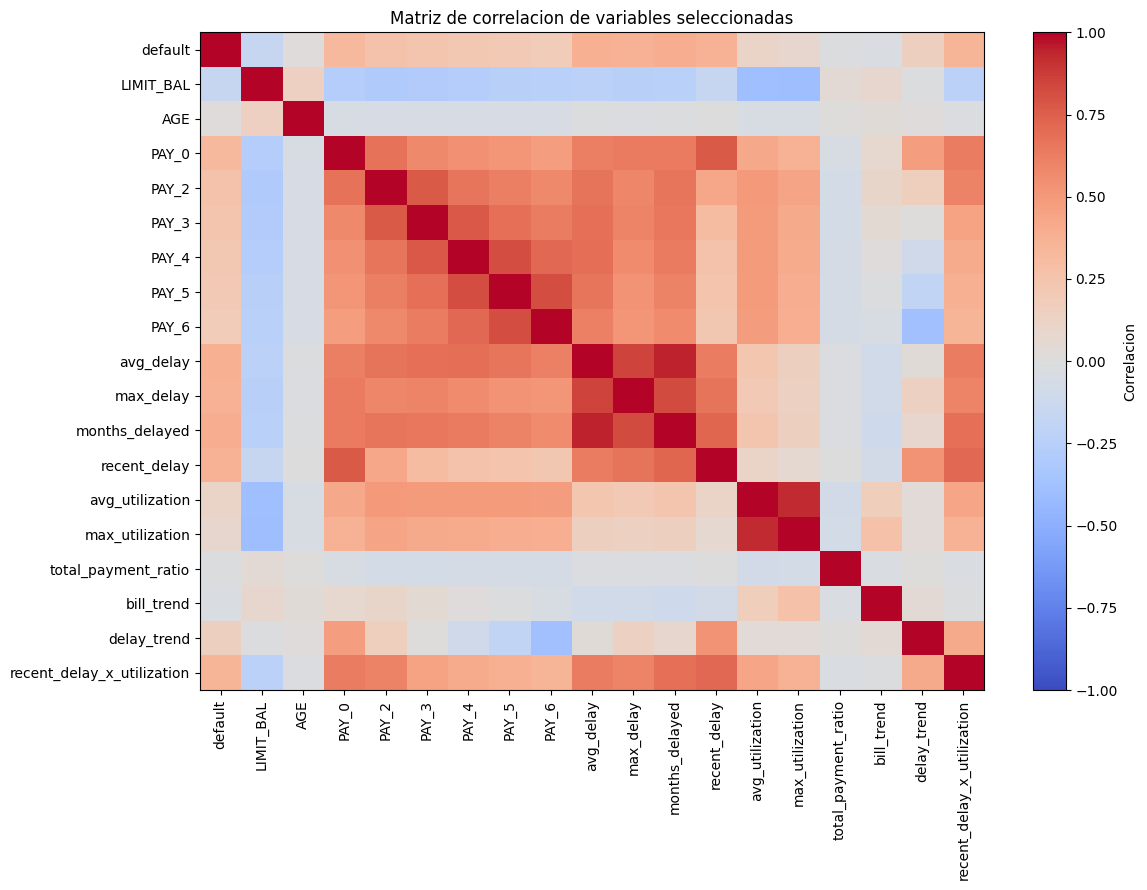

In [ ]:
cols_corr = [
    "default",
    "LIMIT_BAL",
    "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "avg_delay",
    "max_delay",
    "months_delayed",
    "recent_delay",
    "avg_utilization",
    "max_utilization",
    "total_payment_ratio",
    "bill_trend",
    "delay_trend",
    "recent_delay_x_utilization"
]

corr = base[cols_corr].corr()

plt.figure(figsize=(12, 9))
im = plt.imshow(corr, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="Correlacion")
plt.xticks(range(len(cols_corr)), cols_corr, rotation=90)
plt.yticks(range(len(cols_corr)), cols_corr)
plt.title("Matriz de correlacion de variables seleccionadas")
plt.tight_layout()
plt.show()

La matriz de correlación muestra que las variables relacionadas con el historial de atraso forman un bloque altamente correlacionado entre sí y son las que presentan mayor asociación positiva con la variable objetivo. Esto confirma que el comportamiento de pago previo es una de las señales más relevantes para explicar la probabilidad de default. Asimismo, las variables de utilización del crédito presentan correlación positiva moderada con el impago, mientras que LIMIT_BAL mantiene una relación negativa. Aunque existe redundancia entre algunas variables de atraso, esto no representa un problema crítico para modelos basados en árboles como XGBoost, pero debe considerarse al interpretar la importancia de variables.

In [ ]:
#Creamos una copia de la base final para tener un punto limpio antes de crear dummies, train/test etc.
base_final = base.copy()

In [ ]:
# Separamos variable objetivo y variables explicativas

y = base_final["default"]
X = base_final.drop(columns=["default"])

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Dimensión de X: (29965, 33)
Dimensión de y: (29965,)


Como SEX, EDUCATION, MARRIAGE, son categóricas y están codificadas como números, las convertimos a dummies

In [ ]:
# Variables categóricas
cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]

# One-hot encoding
X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

print("Dimensión de X después de dummies:", X.shape)

display(X.head())

Dimensión de X después de dummies: (29965, 36)


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,total_payment_ratio,bill_trend,delay_trend,recent_delay_x_utilization,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,24,2,2,-1,-1,-2,-2,3913.0,3102.0,...,0.089434,3913.0,2,0.0642,1,1,0,0,0,0
2,120000.0,26,-1,2,0,0,0,2,2682.0,1725.0,...,0.292791,-579.0,-2,0.0000,1,1,0,0,1,0
3,90000.0,34,0,0,0,0,0,0,29239.0,14027.0,...,0.108388,13690.0,0,0.0000,1,1,0,0,1,0
4,50000.0,37,0,0,0,0,0,0,46990.0,48233.0,...,0.036259,17443.0,0,0.0000,1,1,0,0,0,0
5,50000.0,57,-1,0,-1,0,0,0,8617.0,5670.0,...,0.540054,-10514.0,0,0.0000,0,1,0,0,0,0


#### Train / test split estratificado

Se realizó una partición train/test con proporción 80/20 y estratificación por la variable objetivo. La estratificación permite conservar la proporción original de clientes con y sin default en ambos conjuntos, evitando que el desbalanceo de clases se concentre artificialmente en alguno de ellos. Esta decisión es relevante porque el modelo debe aprender y evaluarse bajo una distribución representativa del problema original.

Además, se calcula el parámetro scale_pos_weight únicamente con el conjunto de entrenamiento, para evitar fuga de información desde el conjunto de prueba. Este parámetro será utilizado posteriormente en XGBoost para compensar parcialmente el desbalanceo entre la clase mayoritaria y la clase minoritaria.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (23972, 36)
X_test: (5993, 36)
y_train: (23972,)
y_test: (5993,)


In [ ]:
print("Distribución en y_train:")
display(y_train.value_counts(normalize=True).mul(100).to_frame("porcentaje"))

print("Distribución en y_test:")
display(y_test.value_counts(normalize=True).mul(100).to_frame("porcentaje"))

Distribución en y_train:


,porcentaje
default,
0,77.874187
1,22.125813


Distribución en y_test:


,porcentaje
default,
0,77.874187
1,22.125813


In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 3.519607843137255


#### Funciones auxiliares

### Funciones auxiliares

Para no repetir el mismo bloque de evaluación en cada modelo, definimos dos funciones reutilizables: `evaluar_modelo` imprime las métricas y la matriz de confusión y devuelve un diccionario, y `barrido_umbral` recorre distintos umbrales de decisión y devuelve un `DataFrame`. Esto reduce la duplicación de código y el riesgo de errores al copiar y pegar.

In [ ]:
def evaluar_modelo(y_true, y_pred, y_proba, nombre=""):
    "Imprime metricas clave + matriz de confusion y devuelve un dict con las metricas."
    metricas = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }
    if nombre:
        print(f"--- {nombre} ---")
    for k, v in metricas.items():
        print(f"{k:>10}: {v:.4f}")
    print("\nMatriz de confusion:")
    print(confusion_matrix(y_true, y_pred))
    print("\nReporte de clasificacion:")
    print(classification_report(y_true, y_pred, zero_division=0))
    return metricas


def barrido_umbral(y_true, y_proba, umbrales=None):
    "Devuelve un DataFrame con accuracy/precision/recall/F1 para cada umbral."
    if umbrales is None:
        umbrales = np.arange(0.10, 0.91, 0.05)
    filas = []
    for u in umbrales:
        y_pred = (y_proba >= u).astype(int)
        filas.append({
            "umbral": u,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1_score": f1_score(y_true, y_pred, zero_division=0),
        })
    return pd.DataFrame(filas)

### Modelo XGBoost con ajuste de pesos (`scale_pos_weight`)

Entrenamos un primer XGBoost incorporando `scale_pos_weight` para compensar el desbalance de clases. Además de las métricas habituales reportamos el **PR-AUC** (*average precision*), que resume la curva Precision-Recall y es más informativo que el ROC-AUC cuando la clase positiva es minoritaria.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb_base = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=5,
    gamma=0.5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=10,
    reg_alpha=0.1,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_base.fit(X_train, y_train)

y_pred_base = xgb_base.predict(X_test)
y_proba_base = xgb_base.predict_proba(X_test)[:, 1]

metricas_base = evaluar_modelo(
    y_test, y_pred_base, y_proba_base, "XGBoost ponderado (umbral 0.50)"
)

--- XGBoost ponderado (umbral 0.50) ---
  accuracy: 0.7534
 precision: 0.4597
    recall: 0.6531
  f1_score: 0.5396
   roc_auc: 0.7808
    pr_auc: 0.5660

Matriz de confusion:
[[3649 1018]
 [ 460  866]]

Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      4667
           1       0.46      0.65      0.54      1326

    accuracy                           0.75      5993
   macro avg       0.67      0.72      0.69      5993
weighted avg       0.79      0.75      0.77      5993





Para dimensionar el efecto de `scale_pos_weight`, entrenamos un XGBoost con exactamente los mismos hiperparámetros pero sin pesos de clase.

In [ ]:
xgb_sin_pesos = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=5,
    gamma=0.5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=10,
    reg_alpha=0.1,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_sin_pesos.fit(X_train, y_train)

y_pred_sin_pesos = xgb_sin_pesos.predict(X_test)
y_proba_sin_pesos = xgb_sin_pesos.predict_proba(X_test)[:, 1]

metricas_sin_pesos = evaluar_modelo(
    y_test, y_pred_sin_pesos, y_proba_sin_pesos, "XGBoost sin pesos (umbral 0.50)"
)

--- XGBoost sin pesos (umbral 0.50) ---
  accuracy: 0.8205
 precision: 0.6756
    recall: 0.3627
  f1_score: 0.4720
   roc_auc: 0.7817
    pr_auc: 0.5690

Matriz de confusion:
[[4436  231]
 [ 845  481]]

Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4667
           1       0.68      0.36      0.47      1326

    accuracy                           0.82      5993
   macro avg       0.76      0.66      0.68      5993
weighted avg       0.80      0.82      0.80      5993



Al comparar XGBoost con y sin ajuste de pesos de clase, se observa un cambio importante en el comportamiento del modelo. El modelo sin pesos obtiene mayor accuracy y precision, pero presenta un recall bajo para la clase de default, detectando únicamente 36.58% de los clientes que efectivamente caen en impago.

Al incorporar scale_pos_weight, el modelo incrementa el recall de la clase positiva hasta 64.48%, reduciendo considerablemente los falsos negativos. Este cambio es relevante para un problema de riesgo crediticio, ya que dejar pasar clientes que posteriormente caerán en default puede ser más costoso que generar alertas adicionales sobre clientes que finalmente no incumplen.

Por lo tanto, aunque el modelo ponderado sacrifica accuracy y precision, ofrece un mejor equilibrio para identificar clientes con mayor probabilidad de impago.

A continuación realizaremos un tunning de hiperparámetros con validación cruzada

In [ ]:
#Definimos el modelo base para búsqueda
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

In [ ]:
#Definimos el espacio de hiperparámetros
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.25, 0.5, 1, 2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_lambda": [1, 5, 10, 20],
    "reg_alpha": [0, 0.1, 0.5, 1]
}

A continuación utilizaremos StratifiedKFold para conservar la proporción de defaults y no defaults en cada fold

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Con el objetivo de mejorar el desempeño del modelo base, se realiza una búsqueda aleatoria de hiperparámetros utilizando validación cruzada estratificada. La búsqueda se realiza únicamente sobre el conjunto de entrenamiento, evitando utilizar el conjunto de prueba durante el proceso de selección del modelo.

Se utiliza el **PR-AUC (*average precision*)** como métrica de optimización. Dado que el problema está desbalanceado y el interés principal es el desempeño sobre la clase positiva (clientes que caen en *default*), optimizar directamente esta métrica está mejor alineado con el objetivo del proyecto que el ROC-AUC: el PR-AUC se concentra en la precisión y el recall de la clase minoritaria. Posteriormente, una vez seleccionado el mejor modelo, se evalúa su desempeño en el conjunto de prueba y se ajusta el umbral de clasificación.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=40,
    scoring="average_precision",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None...
                   n_iter=40, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.25, 0.5, 1, 2],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [2, 3, 4, 5],
                                        'min_child_weight': [1, 3, 5, 10],
                                        'n_estimators': [100, 200, 300, 500],
                                        'reg_alpha': [0, 0.1, 0.5, 1],
                                        'reg_lambda': [1, 5, 10, 20],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='average_precision', verbose=1)

In [ ]:
print("Mejor PR-AUC (average precision) promedio en CV:", random_search.best_score_)
print("Mejores hiperparámetros:")
print(random_search.best_params_)
xgb_tuned = random_search.best_estimator_

Mejor PR-AUC (average precision) promedio en CV: 0.5671396911428136
Mejores hiperparámetros:
{'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 0.8}


La búsqueda aleatoria identificó una combinación de hiperparámetros con un **PR-AUC** promedio de validación cruzada cercano a 0.57. El mejor modelo mantiene una complejidad controlada mediante regularización (penalizaciones L1/L2, `gamma` y un `min_child_weight` alto), profundidad moderada (`max_depth=5`) y submuestreo de columnas (`colsample_bytree`). A continuación se evalúa este modelo tuneado sobre el conjunto de prueba, que no fue utilizado durante la búsqueda de hiperparámetros.

In [ ]:
y_pred_tuned = xgb_tuned.predict(X_test)
y_proba_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

metricas_tuned = evaluar_modelo(
    y_test, y_pred_tuned, y_proba_tuned, "XGBoost tuneado (umbral 0.50)"
)

--- XGBoost tuneado (umbral 0.50) ---
  accuracy: 0.7586
 precision: 0.4660
    recall: 0.6244
  f1_score: 0.5337
   roc_auc: 0.7807
    pr_auc: 0.5678

Matriz de confusion:
[[3718  949]
 [ 498  828]]

Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      4667
           1       0.47      0.62      0.53      1326

    accuracy                           0.76      5993
   macro avg       0.67      0.71      0.69      5993
weighted avg       0.79      0.76      0.77      5993



In [ ]:
comparacion_modelos = pd.DataFrame(
    [metricas_base, metricas_tuned],
    index=["XGBoost base ponderado", "XGBoost tuneado"]
)
display(comparacion_modelos.round(4))

,accuracy,precision,recall,f1_score,roc_auc,pr_auc
XGBoost base ponderado,0.7534,0.4597,0.6531,0.5396,0.7808,0.5660
XGBoost tuneado,0.7586,0.4660,0.6244,0.5337,0.7807,0.5678


In [ ]:
cm_base = confusion_matrix(y_test, y_pred_base)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

comparacion_confusion_tuned = pd.DataFrame({
    "modelo": ["XGBoost base ponderado", "XGBoost tuneado"],
    "true_negative": [cm_base[0, 0], cm_tuned[0, 0]],
    "false_positive": [cm_base[0, 1], cm_tuned[0, 1]],
    "false_negative": [cm_base[1, 0], cm_tuned[1, 0]],
    "true_positive": [cm_base[1, 1], cm_tuned[1, 1]]
})

display(comparacion_confusion_tuned)

,modelo,true_negative,false_positive,false_negative,true_positive
0,XGBoost base ponderado,3649,1018,460,866
1,XGBoost tuneado,3718,949,498,828


El modelo tuneado presenta un desempeño muy similar al modelo base ponderado. La búsqueda de hiperparámetros mejora marginalmente la accuracy, la precisión y el F1-score, pero no mejora el recall y deja el ROC-AUC y el PR-AUC prácticamente sin cambio; en la matriz de confusión reduce ligeramente los falsos positivos a costa de un leve aumento de falsos negativos.

En otras palabras, el tuning aporta una mejora marginal y no un cambio sustancial en el desempeño predictivo. A continuación ajustamos el umbral de decisión tanto para el modelo base ponderado como para el tuneado —eligiéndolo por validación cruzada sobre el train— y comparamos todas las variantes para seleccionar el modelo final.

### Selección del umbral de decisión

Estimamos probabilidades *out-of-fold* sobre el **conjunto de entrenamiento** con `cross_val_predict` (validación cruzada estratificada).

In [ ]:
from sklearn.model_selection import cross_val_predict

# Probabilidades out-of-fold sobre TRAIN
proba_oof_tuned = cross_val_predict(
    xgb_tuned, X_train, y_train,
    cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

barrido_train = barrido_umbral(y_train, proba_oof_tuned, np.arange(0.10, 0.91, 0.01))
umbral_optimo = float(barrido_train.loc[barrido_train["f1_score"].idxmax(), "umbral"])

print("Umbral optimo (elegido por CV en train):", round(umbral_optimo, 3))

Umbral optimo (elegido por CV en train): 0.56


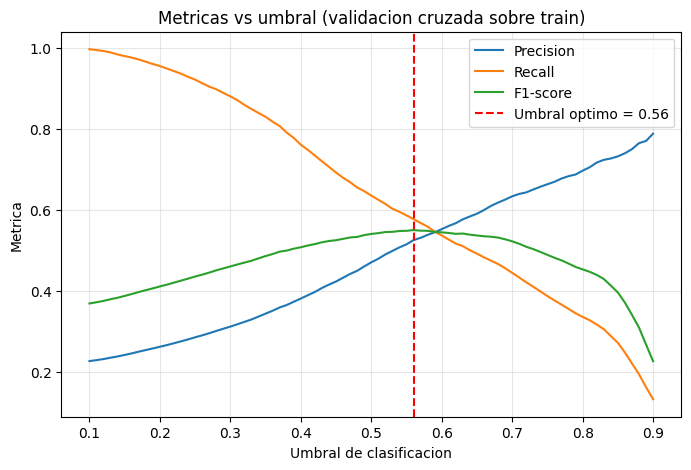

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(barrido_train["umbral"], barrido_train["precision"], label="Precision")
plt.plot(barrido_train["umbral"], barrido_train["recall"], label="Recall")
plt.plot(barrido_train["umbral"], barrido_train["f1_score"], label="F1-score")
plt.axvline(umbral_optimo, color="red", linestyle="--",
            label=f"Umbral optimo = {umbral_optimo:.2f}")
plt.title("Metricas vs umbral (validacion cruzada sobre train)")
plt.xlabel("Umbral de clasificacion")
plt.ylabel("Metrica")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Evaluacion FINAL en test, una sola vez, con el umbral elegido en train
y_pred_tuned_umbral = (y_proba_tuned >= umbral_optimo).astype(int)

metricas_tuned_umbral = evaluar_modelo(
    y_test, y_pred_tuned_umbral, y_proba_tuned,
    f"XGBoost tuneado (umbral {umbral_optimo:.2f}, elegido en train)"
)

--- XGBoost tuneado (umbral 0.56, elegido en train) ---
  accuracy: 0.7878
 precision: 0.5186
    recall: 0.5671
  f1_score: 0.5418
   roc_auc: 0.7807
    pr_auc: 0.5678

Matriz de confusion:
[[3969  698]
 [ 574  752]]

Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4667
           1       0.52      0.57      0.54      1326

    accuracy                           0.79      5993
   macro avg       0.70      0.71      0.70      5993
weighted avg       0.80      0.79      0.79      5993



In [ ]:
# Mismo procedimiento de seleccion de umbral para el modelo base ponderado
proba_oof_base = cross_val_predict(
    xgb_base, X_train, y_train,
    cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

barrido_train_base = barrido_umbral(
    y_train, proba_oof_base, np.arange(0.10, 0.91, 0.01)
)
umbral_base = float(
    barrido_train_base.loc[barrido_train_base["f1_score"].idxmax(), "umbral"]
)
y_pred_base_umbral = (y_proba_base >= umbral_base).astype(int)

print("Umbral optimo base ponderado (CV en train):", round(umbral_base, 3))

Umbral optimo base ponderado (CV en train): 0.58


### Comparación final de modelos

Resumimos todas las variantes evaluadas. Importante: los umbrales distintos de 0.50 fueron elegidos por validación cruzada sobre el train, de modo que la tabla refleja un desempeño honesto sobre el conjunto de prueba. Se reporta también el PR-AUC por el desbalance de clases.

In [ ]:
def fila(nombre, umbral, y_pred, y_proba):
    return {
        "modelo": nombre,
        "umbral": round(float(umbral), 2),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    }

modelos_finales = pd.DataFrame([
    fila("XGBoost sin pesos - umbral 0.50", 0.50, y_pred_sin_pesos, y_proba_sin_pesos),
    fila("XGBoost ponderado - umbral 0.50", 0.50, y_pred_base, y_proba_base),
    fila(f"XGBoost ponderado - umbral {umbral_base:.2f}", umbral_base, y_pred_base_umbral, y_proba_base),
    fila("XGBoost tuneado - umbral 0.50", 0.50, y_pred_tuned, y_proba_tuned),
    fila(f"XGBoost tuneado - umbral {umbral_optimo:.2f}", umbral_optimo, y_pred_tuned_umbral, y_proba_tuned),
]).set_index("modelo")

display(modelos_finales.round(4))


,umbral,accuracy,precision,recall,f1_score,roc_auc,pr_auc
modelo,,,,,,,
XGBoost sin pesos - umbral 0.50,0.50,0.8205,0.6756,0.3627,0.4720,0.7817,0.5690
XGBoost ponderado - umbral 0.50,0.50,0.7534,0.4597,0.6531,0.5396,0.7808,0.5660
XGBoost ponderado - umbral 0.58,0.58,0.7871,0.5171,0.5686,0.5417,0.7808,0.5660
XGBoost tuneado - umbral 0.50,0.50,0.7586,0.4660,0.6244,0.5337,0.7807,0.5678
XGBoost tuneado - umbral 0.56,0.56,0.7878,0.5186,0.5671,0.5418,0.7807,0.5678


### Importancia de variables

A continuación cuantificamos cuánto aporta cada variable a las predicciones (ganancia).

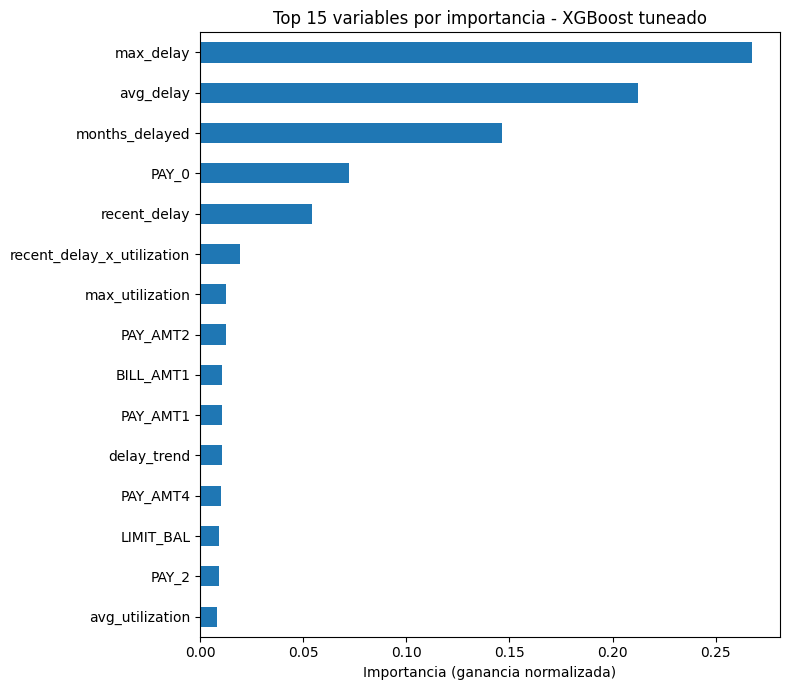

,importancia
max_delay,0.267720
avg_delay,0.212355
months_delayed,0.146205
PAY_0,0.072299
recent_delay,0.054249
recent_delay_x_utilization,0.019280
max_utilization,0.012432
PAY_AMT2,0.012399
BILL_AMT1,0.010709
PAY_AMT1,0.010688


In [ ]:
importancias = (
    pd.Series(xgb_tuned.feature_importances_, index=X_train.columns)
    .sort_values()
)

plt.figure(figsize=(8, 7))
importancias.tail(15).plot(kind="barh")
plt.title("Top 15 variables por importancia - XGBoost tuneado")
plt.xlabel("Importancia (ganancia normalizada)")
plt.tight_layout()
plt.show()

display(importancias.sort_values(ascending=False).head(15).to_frame("importancia"))

### Curvas Precision-Recall y ROC

Con clases desbalanceadas, la curva Precision-Recall (y su área, *Average Precision*) describe mejor el desempeño sobre la clase minoritaria que la curva ROC, que puede lucir optimista. Mostramos ambas para el modelo final.

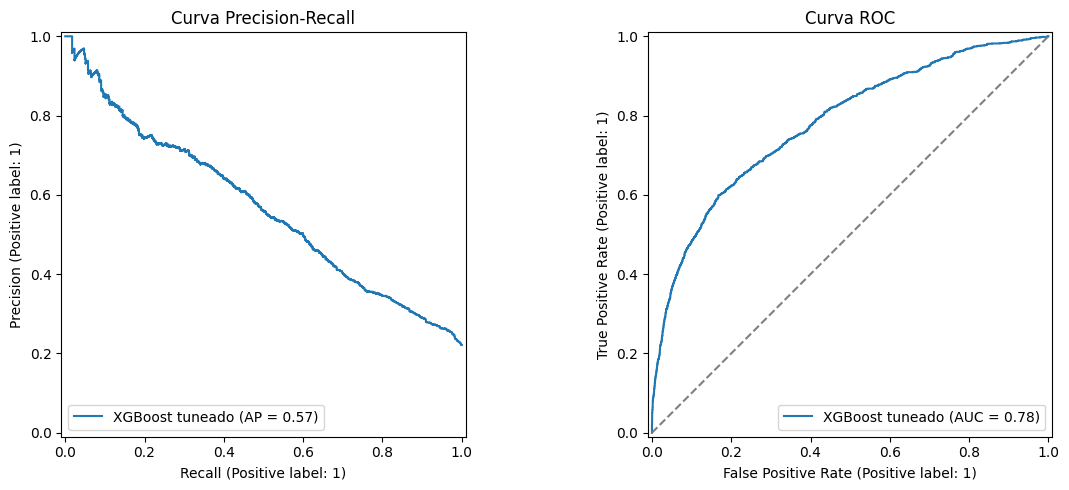

In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

PrecisionRecallDisplay.from_predictions(
    y_test, y_proba_tuned, ax=ax[0], name="XGBoost tuneado"
)
ax[0].set_title("Curva Precision-Recall")

RocCurveDisplay.from_predictions(
    y_test, y_proba_tuned, ax=ax[1], name="XGBoost tuneado"
)
ax[1].plot([0, 1], [0, 1], "--", color="gray")
ax[1].set_title("Curva ROC")

plt.tight_layout()
plt.show()

### Calibración de probabilidades

Al entrenar con `scale_pos_weight`, las probabilidades quedan sesgadas hacia la clase positiva y dejan de interpretarse directamente como probabilidad real de impago. Comparamos la calibración del modelo ponderado contra una versión recalibrada (isotónica) para evidenciar este efecto. Es relevante porque el proyecto se plantea en términos de *probabilidad* de impago.

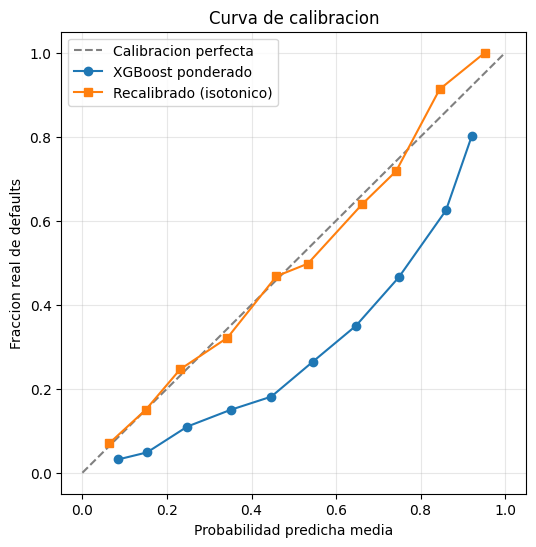

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

xgb_cal = CalibratedClassifierCV(xgb_tuned, method="isotonic", cv=5)
xgb_cal.fit(X_train, y_train)
proba_cal = xgb_cal.predict_proba(X_test)[:, 1]

frac_pos, mean_pred = calibration_curve(y_test, y_proba_tuned, n_bins=10)
frac_pos_c, mean_pred_c = calibration_curve(y_test, proba_cal, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "--", color="gray", label="Calibracion perfecta")
plt.plot(mean_pred, frac_pos, marker="o", label="XGBoost ponderado")
plt.plot(mean_pred_c, frac_pos_c, marker="s", label="Recalibrado (isotonico)")
plt.xlabel("Probabilidad predicha media")
plt.ylabel("Fraccion real de defaults")
plt.title("Curva de calibracion")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Selección del modelo XGBoost final


**Manejo del desbalance.** El modelo sin pesos alcanza la mayor accuracy (0.82) y precisión (0.67), pero su recall sobre la clase de impago es bajo (0.36): deja sin detectar a casi dos de cada tres clientes que efectivamente caen en *default*. Incorporar `scale_pos_weight` eleva el recall a 0.65 a costa de precisión, un intercambio razonable en riesgo crediticio, donde un falso negativo (no detectar a un cliente que incumple) suele ser más costoso que un falso positivo (una alerta que no se materializa).

**Tuning.** La búsqueda aleatoria de hiperparámetros se optimizó directamente sobre el PR-AUC (la métrica objetivo dado el desbalance) y alcanzó un PR-AUC promedio en CV de ~0.57. Aun así, **sobre el conjunto de prueba no aportó mejora**: el modelo tuneado y el base ponderado obtienen un desempeño prácticamente idéntico (ROC-AUC ≈ 0.78, PR-AUC ≈ 0.57). Esto refuerza que la configuración inicial ya era razonable y que conviene preferir el modelo más simple.

**Umbral.** El umbral óptimo por F1 resultó 0.58 y 0.56 para el tuneado;aplicado al test, mejora el F1 frente al umbral 0.50 en ambos modelos.

**Variables más relevantes.** La importancia del modelo está dominada por las variables de atraso construidas (`max_delay`, `avg_delay`, `recent_delay`, `months_delayed`) junto con `PAY_0`. Esto valida el *feature engineering* y es coherente con el análisis exploratorio: el comportamiento de pago reciente y la persistencia del atraso son las señales más informativas del impago.

**Modelo final.** El modelo seleccionado es el XGBoost con ajuste de pesos (scale_pos_weight) y umbral de clasificación 0.50.
Considerando que en riesgo crediticio el error más costoso es el falso negativo: clasificar como buen pagador a un cliente que terminará en impago implica una pérdida directa, normalmente mayor que el costo de una falsa alarma (revisar o rechazar a un cliente que sí habría pagado). Por ello priorizamos el recall de la clase de impago, acompañado del PR-AUC, que evalúa la discriminación sobre la clase minoritaria de forma independiente del umbral.

En comparativa, los cinco modelos presentan un PR-AUC y un ROC-AUC prácticamente idénticos (PR-AUC ≈ 0.569; ROC-AUC ≈ 0.78), de modo que su capacidad de discriminación es equivalente y las diferencias están dentro del margen de ruido. La decisión, por tanto, no recae sobre la capacidad de ordenamiento del modelo sino sobre el punto de operación. Dado que el objetivo es maximizar la detección de clientes en riesgo de impago, se selecciona el XGBoost ponderado con umbral 0.50, que ofrece el mejor recall (0.65) manteniendo una discriminación equivalente al resto (PR-AUC 0.569, ROC-AUC 0.781). En términos operativos, sobre el conjunto de prueba el modelo identifica correctamente a 866 de los 1,326 clientes que caen en impago (65.3%), a cambio de 1,018 falsas alarmas sobre 4,667 clientes que no incumplen. Este intercambio es razonable cuando el costo de un impago no detectado supera al de una revisión adicional.

___
## Red Neuronal

---
## 4. Red Neuronal — MLP (Perceptrón Multicapa)

### Arquitectura
```
Input (33 features)
    │
    ▼
[Dense 32, ReLU]  ← Capa oculta 1
    │
    ▼
[Dense 1, Sigmoid] ← Salida (probabilidad de default)
```


Iniciando comparación de configuraciones...

(32,) | relu | alpha=0.01 | AUC=0.7680
(64,) | relu | alpha=0.01 | AUC=0.7700
(32,) | tanh | alpha=0.001 | AUC=0.7689
(64,) | tanh | alpha=0.001 | AUC=0.7656
(32,) | tanh | alpha=0.0001 | AUC=0.7683
(64,) | tanh | alpha=0.0001 | AUC=0.7656
(64, 32) | relu | alpha=0.001 | AUC=0.7555
(64, 32) | tanh | alpha=0.001 | AUC=0.7669
(128, 64) | relu | alpha=0.001 | AUC=0.7677
(128, 64) | tanh | alpha=0.001 | AUC=0.7618
(64, 32) | relu | alpha=0.0001 | AUC=0.7604
(64, 32, 128) | relu | alpha=0.01 | AUC=0.7694
(64, 128, 32) | relu | alpha=0.01 | AUC=0.7699
(128, 32, 64) | relu | alpha=0.01 | AUC=0.7665
(128, 64, 32) | relu | alpha=0.01 | AUC=0.7563
(32, 128, 64) | relu | alpha=0.01 | AUC=0.7642


RESULTADOS ORDENADOS POR ROC-AUC


,Capas,Activacion,Alpha,ROC_AUC,Precision_Clase1,Recall_Clase1,F1_Clase1,Epocas
0,"(64,)",relu,0.0100,0.7700,0.5191,0.5422,0.5304,41
1,"(64, 128, 32)",relu,0.0100,0.7699,0.5041,0.5618,0.5314,25
2,"(64, 32, 128)",relu,0.0100,0.7694,0.5513,0.5023,0.5257,25
3,"(32,)",tanh,0.0010,0.7689,0.5347,0.5226,0.5286,33
4,"(32,)",tanh,0.0001,0.7683,0.5220,0.5460,0.5337,50
5,"(32,)",relu,0.0100,0.7680,0.4868,0.5701,0.5252,33
6,"(128, 64)",relu,0.0010,0.7677,0.4961,0.5732,0.5318,26
7,"(64, 32)",tanh,0.0010,0.7669,0.5295,0.5279,0.5287,36
8,"(128, 32, 64)",relu,0.0100,0.7665,0.4758,0.5928,0.5279,24
9,"(64,)",tanh,0.0010,0.7656,0.5061,0.5618,0.5325,27




MEJOR CONFIGURACIÓN
Capas                (64,)
Activacion            relu
Alpha                 0.01
ROC_AUC               0.77
Precision_Clase1    0.5191
Recall_Clase1       0.5422
F1_Clase1           0.5304
Epocas                  41
Name: 0, dtype: object


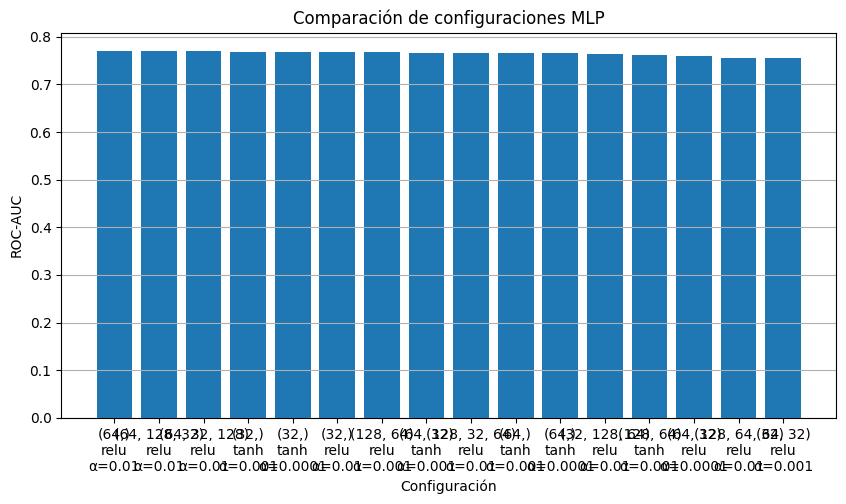

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve
)

#Configuraciones posibles con relu y tanh
configuraciones = [
    ((32,),  'relu', 1e-2),
    ((64,),  'relu', 1e-2),
    ((32,),  'tanh', 1e-3),
    ((64,),  'tanh', 1e-3),
    ((32,),  'tanh', 1e-4),
    ((64,),  'tanh', 1e-4),
    ((64,32),  'relu', 1e-3),
    ((64,32),  'tanh', 1e-3),
    ((128,64), 'relu', 1e-3),
    ((128,64), 'tanh', 1e-3),
    ((64,32),  'relu', 1e-4),
    ((64,32,128),  'relu', 1e-2),
    ((64,128,32),  'relu', 1e-2),
    ((128,32,64),  'relu', 1e-2),
    ((128,64,32),  'relu', 1e-2),
    ((32,128,64),  'relu', 1e-2),
]

resultados = []

print("Iniciando comparación de configuraciones...\n")

for capas, activacion, alpha in configuraciones:

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(
            hidden_layer_sizes=capas,
            activation=activacion,
            solver='adam',
            alpha=alpha,
            batch_size=256,
            learning_rate_init=1e-3,
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            random_state=42,
            verbose=False
        ))
    ])

    pipe.fit(X_train, y_train)

    modelo = pipe.named_steps['model']

    proba = pipe.predict_proba(X_test)[:,1]

    precision, recall, thresholds = precision_recall_curve(
        y_test,
        proba
    )

    f1_scores = (
        2 * precision * recall
        / (precision + recall + 1e-10)
    )

    best_idx = f1_scores.argmax()

    if best_idx >= len(thresholds):
        best_idx = len(thresholds) - 1

    best_threshold = thresholds[best_idx]

    y_pred = (proba >= best_threshold).astype(int)

    reporte = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    auc = roc_auc_score(y_test, proba)

    resultados.append({
        "Capas": str(capas),
        "Activacion": activacion,
        "Alpha": alpha,
        "ROC_AUC": round(auc, 4),
        "Precision_Clase1": round(reporte['1']['precision'], 4),
        "Recall_Clase1": round(reporte['1']['recall'], 4),
        "F1_Clase1": round(reporte['1']['f1-score'], 4),
        "Epocas": modelo.n_iter_
    })

    print(
        f"{capas} | "
        f"{activacion} | "
        f"alpha={alpha} | "
        f"AUC={auc:.4f}"
    )


df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(
    by="ROC_AUC",
    ascending=False
).reset_index(drop=True)

print("\n")
print("="*60)
print("RESULTADOS ORDENADOS POR ROC-AUC")
print("="*60)

display(df_resultados)


mejor = df_resultados.iloc[0]

print("\n")
print("="*60)
print("MEJOR CONFIGURACIÓN")
print("="*60)

print(mejor)


etiquetas = [
    f"{row['Capas']}\n{row['Activacion']}\nα={row['Alpha']}"
    for _, row in df_resultados.iterrows()
]

plt.figure(figsize=(10,5))

plt.bar(
    etiquetas,
    df_resultados["ROC_AUC"]
)

plt.ylabel("ROC-AUC")
plt.xlabel("Configuración")
plt.title("Comparación de configuraciones MLP")

plt.grid(axis='y')

plt.show()

In [26]:
# Pipeline del MLP
pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(
        hidden_layer_sizes=(64,),
        activation='relu',
        solver='adam',
        alpha=1e-2,
        batch_size=256,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=42,
        verbose=False
    ))
])

# Valdiación cruzada k-fold

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

auc_scores = cross_val_score(
    pipe_mlp,
    X_train,
    y_train,
    cv=kfold,
    scoring="roc_auc",
    n_jobs=-1
)

print("Resultados ROC-AUC por fold:")
print(auc_scores)

print("\nAUC promedio:", auc_scores.mean())
print("Desviación estándar:", auc_scores.std())

# Entrenamiento final

pipe_mlp.fit(X_train, y_train)

mlp = pipe_mlp.named_steps['model']

print("\nMLP entrenado con todo el conjunto de entrenamiento")
print(f"Épocas entrenadas: {mlp.n_iter_}")
print(f"Loss final de entrenamiento: {mlp.loss_:.4f}")


# Evaluación en test


proba = pipe_mlp.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, proba)

f1_scores = 2 * precision * recall / (precision + recall + 1e-10)

best_idx = f1_scores[:-1].argmax()
best_threshold = thresholds[best_idx]

y_pred = (proba >= best_threshold).astype(int)

print("\nMejor threshold:", best_threshold)

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, proba)

print("ROC-AUC en test:", roc_auc)

Resultados ROC-AUC por fold:
[0.78174386 0.77938103 0.77246314 0.76701619 0.78104877]

AUC promedio: 0.7763305970647422
Desviación estándar: 0.005702369076829924

MLP entrenado con todo el conjunto de entrenamiento
Épocas entrenadas: 41
Loss final de entrenamiento: 0.4150

Mejor threshold: 0.27454399542746305

Matriz de confusión:
[[4001  666]
 [ 607  719]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      4667
           1       0.52      0.54      0.53      1326

    accuracy                           0.79      5993
   macro avg       0.69      0.70      0.70      5993
weighted avg       0.79      0.79      0.79      5993

ROC-AUC en test: 0.7700128723837114


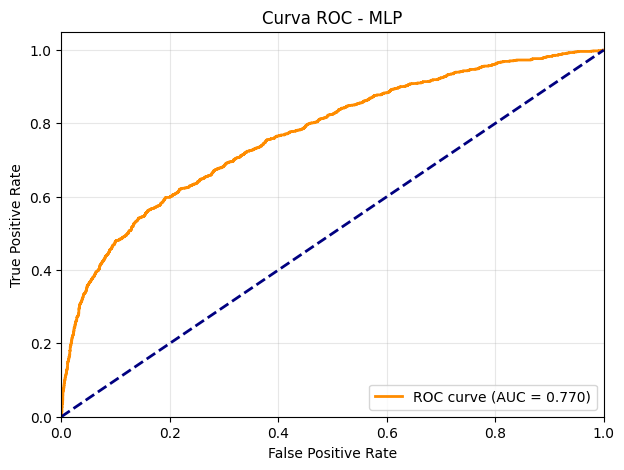

In [27]:
# Curva ROC AUC
fpr, tpr, thresholds = roc_curve(y_test, proba)
roc_auc = roc_auc_score(y_test, proba)

# Gráfica
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - MLP")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

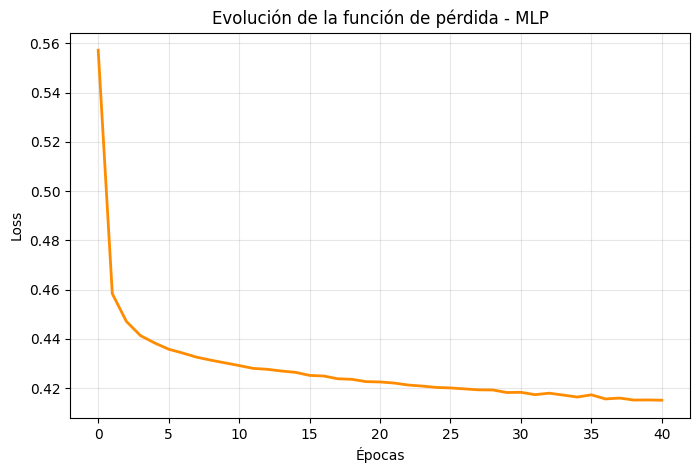

In [28]:
# Evolución de la función de pérdida
plt.figure(figsize=(8,5))
plt.plot(mlp.loss_curve_, color="darkorange", lw=2)
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Evolución de la función de pérdida - MLP")
plt.grid(alpha=0.3)
plt.show()